# Package Loaded

In [92]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Time series
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler


# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm


# Utilities 

In [93]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q

In [94]:
def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages, long-run coverage (LRC), 
    rolling coverage, and time-conditional coverage.

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    #scores_val = scores[::2]
    #scores = scores[1::2]
    T = len(scores)
    #N_val = len(scores_val)
    
    # Define learning rates
    #etas_fixed = np.ones(T) * fixed_step_size
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Compute the oracle quantile
    #q_star = np.quantile(scores, 1 - alpha)
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    #q_fixed = get_online_quantile(scores, q_1, etas_fixed, alpha)
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    #observed_coverages_fixed = (scores <= q_fixed).astype(int)
    observed_coverages_decaying = (scores <= q_decaying).astype(int)
    #observed_coverages_oracle = (scores <= q_star).astype(int)

    # Compute long-run coverage
    #LRC_fixed = np.cumsum(observed_coverages_fixed) / (np.arange(len(observed_coverages_fixed)) + 1)
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)
    #LRC_qstar = np.cumsum(observed_coverages_oracle) / (np.arange(len(observed_coverages_oracle)) + 1)

    # Compute rolling coverage
    #rolling_coverage_fixed = smooth_array(observed_coverages_fixed, W)
    #rolling_coverage_decaying = smooth_array(observed_coverages_decaying, W)
    #rolling_coverage_oracle = smooth_array(observed_coverages_oracle, W)

    # Compute time-conditional coverage
    #time_coverage_fixed = (scores_val[:,None] <= q_fixed[None,:]).mean(axis=0)
    #time_coverage_decaying = (scores_val[:,None] <= q_decaying[None,:]).mean(axis=0)
    #time_coverage_qstar = (scores_val[:,None] <= q_star*np.ones_like(q_decaying)[None,:]).mean(axis=0)

    return {
        "T":T,
        #"q_fixed": q_fixed,
        "q_decaying": q_decaying,
        #"q_star": q_star,
        #"observed_coverages_fixed": observed_coverages_fixed,
        "observed_coverages_decaying": observed_coverages_decaying,
        #"observed_coverages_oracle": observed_coverages_oracle,
        #"LRC_fixed": LRC_fixed,
        "LRC_decaying": LRC_decaying,
        #"LRC_qstar": LRC_qstar,
        #"rolling_coverage_fixed": rolling_coverage_fixed,
        #"rolling_coverage_decaying": rolling_coverage_decaying,
        #"rolling_coverage_oracle": rolling_coverage_oracle,
        #"time_coverage_fixed": time_coverage_fixed,
        #"time_coverage_decaying": time_coverage_decaying,
        #"time_coverage_qstar": time_coverage_qstar
    }

In [ ]:
def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")

    # ---- Plot 1: Quantiles ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Long-run coverage ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
    plt.axhline(y=1 - alpha, linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

In [443]:

def causal_ma(y, w):
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=w, min_periods=w).mean().shift(1).to_numpy()

In [97]:
# SARIMAX

def rolling_sarimax_forecast(data, train_size, p, d, q):
    """
    Perform rolling next-step forecasting using SARIMAX with state-space updates.

    Parameters:
        data (pd.Series): Time series data.
        train_size (int): Number of initial training points.
        p (int): AR order.
        d (int): Differencing order.
        q (int): MA order.

    Returns:
        np.array: Rolling one-step-ahead forecast predictions.
    """
    rolling_predictions = []
    
    # Initial training data
    train_data = data.iloc[:train_size].copy()

    # Fit SARIMAX model on initial training data
    sarimax_model = SARIMAX(train_data, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # Rolling forecast: Predict one step, update model iteratively
    for t in tqdm(range(len(data) - train_size)):
        # Predict the next value
        next_pred = sarimax_model.forecast(steps=1).values[0]
        rolling_predictions.append(next_pred)
        new_obs = data.iloc[train_size + t]
        sarimax_model = sarimax_model.append([new_obs], refit=False)  

    return np.array(rolling_predictions)

In [550]:
from sklearn.metrics import mean_squared_error
import itertools
import numpy as np
import pandas as pd

def sarimax_grid_search(observed_data, y_true_test, train_size,
                        p_values, d_values, q_values,
                        verbose=True, return_table=False):
    """
    Grid search for SARIMAX using your rolling_sarimax_forecast().

    Parameters
    ----------
    observed_data : pd.Series or array-like
        Full observed series used to fit/append (length = n).
    y_true_test : pd.Series or array-like
        Ground-truth targets for t = train_size ... n-1
        (length should be n - train_size).
    train_size : int
        Initial training size used inside rolling_sarimax_forecast.
    p_values, d_values, q_values : list[int]
        Candidate SARIMAX orders.
    verbose : bool
        Print progress.
    return_table : bool
        If True, also return a DataFrame of all configs and RMSE.

    Returns
    -------
    best_cfg : tuple (p, d, q)
    best_score : float (RMSE)
    results_df : pd.DataFrame (optional)
    """
    # Coerce to proper dtypes
    if not isinstance(observed_data, pd.Series):
        observed_data = pd.Series(np.asarray(observed_data))
    y_true_test = np.asarray(y_true_test).astype(float)

    n = len(observed_data)
    expected_len = n - train_size
    if expected_len <= 0:
        raise ValueError(f"train_size={train_size} leaves no test points (n={n}).")

    # If user-provided y_true_test length differs, we'll align by truncation
    if len(y_true_test) != expected_len and verbose:
        print(f"⚠️  y_true_test length ({len(y_true_test)}) "
              f"!= expected ({expected_len}). Will align by min length.")
    results = []

    best_score, best_cfg = np.inf, None

    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            preds = rolling_sarimax_forecast(observed_data, train_size, p, d, q)
            preds = np.asarray(preds).astype(float)

            # Check/align lengths
            m = min(len(preds), len(y_true_test))
            if m == 0:
                if verbose:
                    print(f"⏭️  Skipping SARIMAX({p},{d},{q}) — zero-length alignment.")
                continue

            y_true = y_true_test[-m:]
            y_pred = preds[-m:]

            rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
            results.append({"p": p, "d": d, "q": q, "rmse": rmse})

            if verbose:
                print(f"SARIMAX({p},{d},{q}) RMSE={rmse:.4f}")

            if rmse < best_score:
                best_score, best_cfg = rmse, (p, d, q)

        except Exception as e:
            if verbose:
                print(f"SARIMAX({p},{d},{q}) failed: {e}")
            continue

    if not results:
        raise RuntimeError("All configurations failed or produced empty predictions.")

    if verbose:
        print(f"✅ Best SARIMAX{best_cfg} RMSE={best_score:.4f}")

    if return_table:
        return best_cfg, best_score, pd.DataFrame(results).sort_values("rmse")
    return best_cfg, best_score

In [570]:
def create_sequences(data, seq_length, train_ratio=0.8):
    data = np.array(data)  # ensure numpy
    data_len = len(data)
    train_size = int(data_len * train_ratio)

    train_data = data[:train_size]
    test_data  = data[train_size:]  # strict split

    # Training sequences
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length])

    # Testing sequences
    X_test, y_test = [], []
    for i in range(len(test_data) - seq_length):
        X_test.append(test_data[i:i+seq_length])
        y_test.append(test_data[i+seq_length])

    # Reshape for LSTM [samples, timesteps, features]
    X_train = np.array(X_train).reshape(-1, seq_length, 1)
    y_train = np.array(y_train)
    X_test  = np.array(X_test).reshape(-1, seq_length, 1)
    y_test  = np.array(y_test)

    return X_train, X_test, y_train, y_test

In [1216]:
# COMA 


def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.6)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

# Experiment

## ELEC2

## Jump Diffusion 

### sigma = 0.2, lamb = 0.1, mu_j = -0.1, sigma_j = 0.3
Balanced case: diffusion-driven with occasional downward jumps.

#### Visualization 

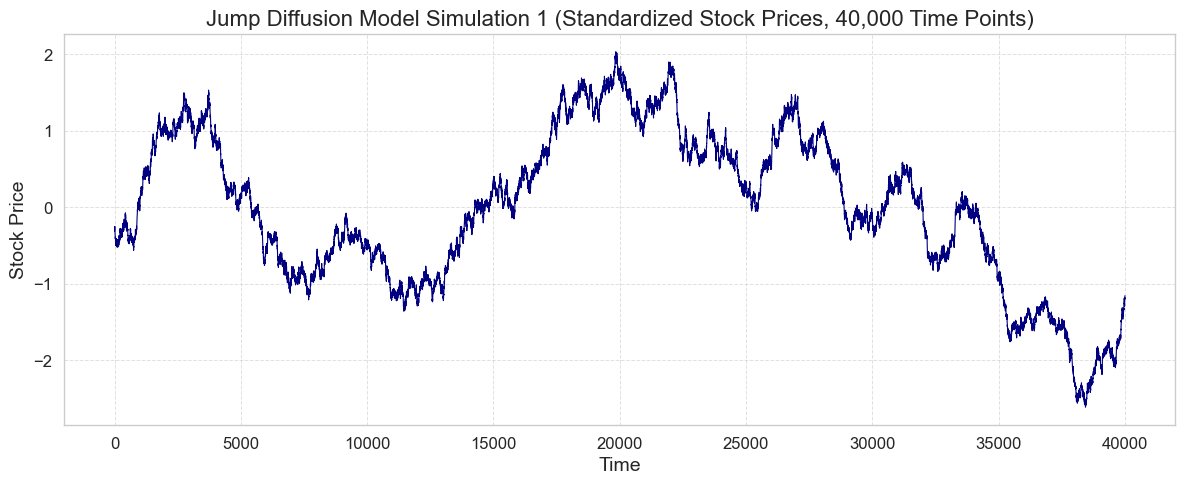

In [1116]:
# Set seed for reproducibility
np.random.seed(42)

# Parameters
S0 = 100                # initial stock price
mu = 0.05               # drift
sigma = 0.2             # volatility
lamb = 0.1              # jump intensity (average 0.1 jumps per unit time)
mu_j = -0.1             # mean jump size (log-normal)
sigma_j = 0.3           # std dev of jump size (log-normal)
T = 1.0                 # total time
N = 40000               # number of time steps
dt = T / N              # time step

# Time grid
t = np.arange(N)

# Brownian increments
dW = np.random.normal(0, np.sqrt(dt), N)

# Poisson jump component
N_jumps = np.random.poisson(lamb * dt, N)  # 0 or 1 jumps per step
J = np.random.normal(mu_j, sigma_j, N)     # jump sizes
jump_component = (np.exp(J) - 1) * N_jumps

# Initialize price path
S = np.zeros(N)
S[0] = S0

# Simulate path
for i in range(1, N):
    S[i] = S[i-1] * (1 + mu * dt + sigma * dW[i] + jump_component[i])

scaler = StandardScaler()
S_sd = scaler.fit_transform(S.reshape(-1, 1)).flatten()


data_jd_sd = pd.DataFrame({'x': t, 'y': S_sd})
# y_observed = y + noise 
# y_true 

# Plot
plt.figure(figsize=(12, 5))

# Plot with publication style
plt.plot(data_jd_sd['x'], data_jd_sd['y'], color="navy", linewidth=0.8)

# Titles and labels
plt.title('Jump Diffusion Model Simulation 1 (Standardized Stock Prices, 40,000 Time Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid & frame
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)

# Clean frame
plt.tight_layout()
plt.show()

#### Train-Test Split

In [ ]:
# Train-test split 
noise = np.random.normal(0, 0.2, size=S_sd.shape)
y_observed = data_jd_sd['y'] + noise 
train_size3 = int(0.8 * len(y_observed))
test_size = int(0.2 * len(y_observed))

y_train_sim3 = y_observed[:train_size3]
y_test_sim3 = y_observed[train_size3:]
y_true = data_jd_sd['y'].to_numpy()
y_true_test = data_jd_sd['y'].to_numpy()[train_size3:] 


print(f"Train dataset shape: {y_train_sim3.shape}, Test dataset shape: {y_test_sim3.shape}")



Train dataset shape: (32000,), Test dataset shape: (8000,)


#### Base Learners

##### Smooth Array 

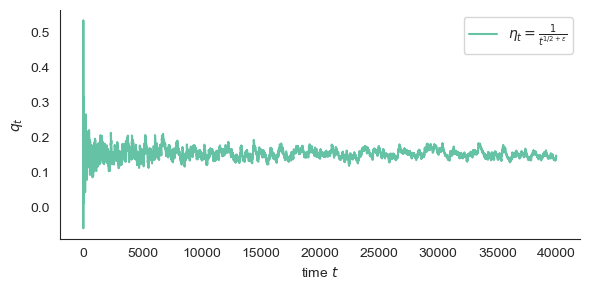

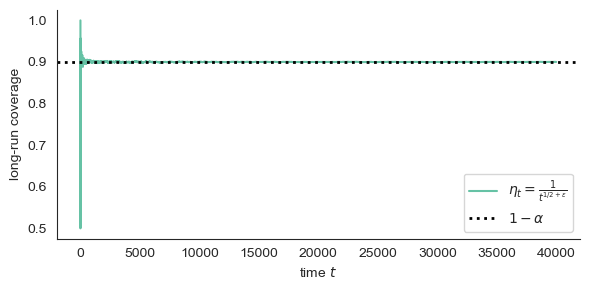

In [690]:
# Get predictions
yhat_sa_jd = causal_ma(y_observed.to_numpy(), w=5)

yhat_sa_jd = np.asarray(yhat_sa_jd, dtype=float)

valid = ~np.isnan(yhat_sa_jd)
y_true_jd = y_true[valid]
yhat_sa_jd = yhat_sa_jd[valid]
# Compute coverage
results_jd_sa = compute_coverage_metrics(
    y_true_jd,
    yhat_sa_jd,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_jd_sa, alpha=0.1, W=1000)
CI_ma_decaying = results_jd_sa['q_decaying'] * 2

In [630]:
print(f'mean coverage for moving average is:', np.mean(results_jd_sa['observed_coverages_decaying']))

mean coverage for moving average is: 0.9001375171896487


##### SARIMAX

In [551]:
best_cfg, best_score = sarimax_grid_search(
    y_observed,           # pd.Series (observed)
    y_true_test,          # ground-truth test target (e.g., true series[train_size:])
    train_size3,
    p_values=[1,2],
    d_values=[0,1,2],
    q_values=[0,1,2]
)

print(f"Best SARIMAX parameters: p={best_cfg[0]}, d={best_cfg[1]}, q={best_cfg[2]}")
print(f"Best RMSE: {best_score:.4f}")

100%|██████████| 8000/8000 [09:37<00:00, 13.84it/s] 


SARIMAX(1,0,0) RMSE=0.2054


100%|██████████| 8000/8000 [09:50<00:00, 13.55it/s]


SARIMAX(1,0,1) RMSE=0.0549


100%|██████████| 8000/8000 [11:12<00:00, 11.89it/s]


...

SARIMAX(2,2,0) RMSE=0.2464


100%|██████████| 8000/8000 [11:49<00:00, 11.28it/s]


SARIMAX(2,2,1) RMSE=0.1182


100%|██████████| 8000/8000 [14:05<00:00,  9.47it/s]

SARIMAX(2,2,2) RMSE=0.0548
✅ Best SARIMAX(1, 1, 2) RMSE=0.0548
Best SARIMAX parameters: p=1, d=1, q=2
Best RMSE: 0.0548


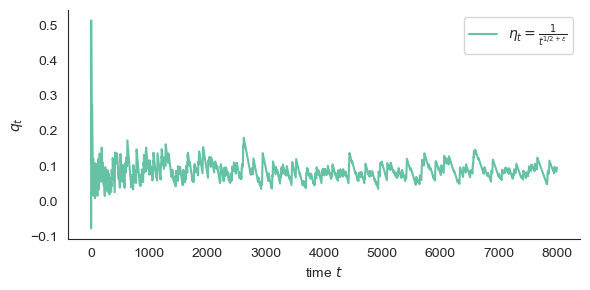

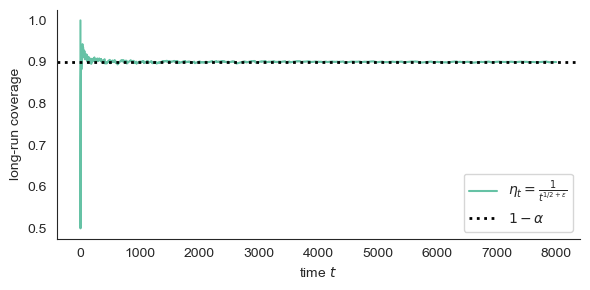

0.08663479421272519


In [ ]:
Yhat_jd_srm_model1 = rolling_sarimax_forecast(y_observed, train_size3, p=1, d=1, q=2)
Y_jd_srm_model1 = np.array(y_true_test)
results_jd_srm_model1 = compute_coverage_metrics(Y_jd_srm_model1, Yhat_jd_srm_model1, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_srm_model1, alpha=0.1, W=1000)
print(np.mean(results_jd_srm_model1['q_decaying']))
CI_sarimax_decaying_model1 = results_jd_srm_model1['q_decaying'] * 2 

In [631]:
print(f'mean coverage for SARIMAX is:', np.mean(results_jd_srm_model1['observed_coverages_decaying']))

mean coverage for SARIMAX is: 0.89975


##### LSTM

###### Grid Search for LSTM 

In [699]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from sklearn.model_selection import train_test_split

seq_length = 15
X_train, X_test, y_train, y_test = create_sequences(y_observed, seq_length, train_ratio = 0.8)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, shuffle=False
)
# --- Define Tunable Model ---
def build_model(hp):
    model = Sequential()
    
    # Tune LSTM units
    hp_units_1 = hp.Int('units_1', min_value=64, max_value=256, step=32)
    hp_units_2 = hp.Int('units_2', min_value=32, max_value=128, step=32)
    
    # Tune dropout
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    
    # Tune learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
    
    model.add(LSTM(hp_units_1, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)))
    model.add(Dropout(hp_dropout))
    model.add(LSTM(hp_units_2, activation='tanh'))
    model.add(Dropout(hp_dropout))
    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    return model

# --- Tuner Setup (overwrite=True ensures fresh search) ---
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=15,              # more trials = better search
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='stock_prediction',
    overwrite=True              # ensures it restarts from scratch
)

# Grid search 
print("Starting hyperparameter search...")
tuner.search(
    X_train, y_train,
    epochs=30,                  # longer, but early stopping will cut short
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# --- Get Best Hyperparameters ---
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n--- Search Complete ---")
print(f"Optimal units in LSTM Layer 1: {best_hps.get('units_1')}")
print(f"Optimal units in LSTM Layer 2: {best_hps.get('units_2')}")
print(f"Optimal dropout rate: {round(best_hps.get('dropout'), 2)}")
print(f"Optimal learning rate: {best_hps.get('learning_rate')}")
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

# This is the epoch where val_loss was lowest
best_epoch = best_trial.best_step
print("Best epoch found:", best_epoch)
# --- Train Final Model ---
print("\nTraining the final model with the best hyperparameters...")
#final_model = tuner.hypermodel.build(best_hps)
#history = final_model.fit(
    #X_train, y_train,
    #epochs=50,
    #batch_size=16,
    #verbose = 0
#)
#best_epoch = np.argmin(history.history['val_loss']) + 1
##print("Best epoch:", best_epoch)

# --- Predict & Evaluate ---
#y_pred_lstm_final = final_model.predict(X_test).flatten()
#results_jd_lstm_final = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm_final, alpha=0.1, epsilon=0.1, W=1000, C=1)
#plot_coverage_results(results_jd_lstm_final, alpha=0.1, W=1000)

Trial 15 Complete [00h 03m 38s]
val_loss: 0.045045673847198486

Best val_loss So Far: 0.045015618205070496
Total elapsed time: 01h 18m 05s

--- Search Complete ---
Optimal units in LSTM Layer 1: 256
Optimal units in LSTM Layer 2: 96
Optimal dropout rate: 0.3
Optimal learning rate: 0.0005
Best epoch found: 4

Training the final model with the best hyperparameters...


###### lstm model1(good learner)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


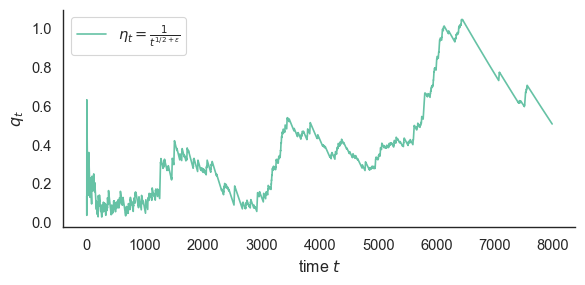

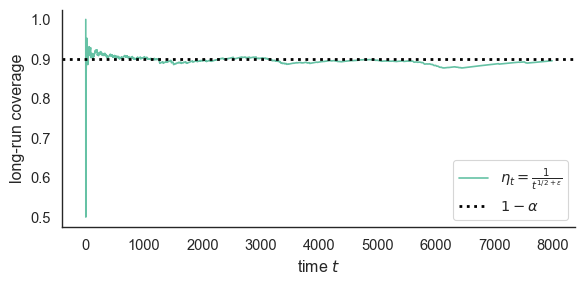

0.41657750368031227


In [765]:
from tensorflow.keras.layers import Dropout


seq_length = 15

X_train, X_test, y_train, y_test = create_sequences(y_observed, seq_length, train_ratio = 0.8)

model = Sequential([
    LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.3),
    LSTM(96, activation='tanh'),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=4, batch_size= 16, verbose = 0)
y_pred_lstm_sim3_model1 = model.predict(X_test).flatten()


results_jd_lstm3_model1 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm_sim3_model1, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm3_model1, alpha=0.1, W=1000)
print(np.mean(results_jd_lstm3_model1['q_decaying']))
CI_lstm_decaying_model1 = results_jd_lstm3_model1['q_decaying'] * 2


In [702]:
print(f'mean coverage for LSTM is:', np.mean(results_jd_lstm3_model1['observed_coverages_decaying']))

mean coverage for LSTM is: 0.9003130870381966


#### Model Aggregation 

##### Super Learner 

###### moderate learners

In [703]:
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# --- Parameters ---
seq_length = 15
n_splits = 5
sarimax_configs = [(1,1,2)]
lstm_configs = [ {"units1": 256, "units2": 96, "dropout": 0.3}]
ma_windows = [5]

data_scaled = y_observed.values.astype(float)
n_total = len(data_scaled)
train_size = int(0.8 * n_total)

# Number of base learners
n_learners = len(ma_windows) + len(sarimax_configs) + len(lstm_configs)

meta_features = np.full((train_size - seq_length, n_learners), np.nan)
meta_targets  = y_true[seq_length:train_size]
train_data_scaled = data_scaled[:train_size]

tscv = TimeSeriesSplit(n_splits=n_splits)

X_all, _, y_all, _ = create_sequences(data_scaled, seq_length, train_ratio=0.8)
for fold, (train_idx, val_idx) in enumerate(tscv.split(train_data_scaled)):
    col = 0

    # ensure val_idx has only usable points
    mask = val_idx >= seq_length
    if not np.any(mask):
        continue
    val_idx_eff = val_idx[mask]
    rows = val_idx_eff - seq_length

    # SARIMAX
    for (p,d,q) in sarimax_configs:
        sarimax_preds = rolling_sarimax_forecast(
            pd.Series(train_data_scaled[:val_idx[-1]+1]), len(train_idx), p, d, q
        )[-len(val_idx):]
        meta_features[rows, col] = sarimax_preds[mask]
        col += 1

    # MA
    for w in ma_windows:
        ma_smoothed = causal_ma(train_data_scaled[:val_idx[-1]+1], w)
        meta_features[rows, col] = ma_smoothed[val_idx_eff]
        col += 1

    # LSTM
    tr_rows = train_idx[train_idx >= seq_length] - seq_length
    va_rows = val_idx_eff - seq_length

    X_tr, y_tr = X_all[tr_rows], y_all[tr_rows]
    X_va, y_va = X_all[va_rows], y_all[va_rows]

    for config in lstm_configs:
        lstm_model = Sequential([
            LSTM(config["units1"], activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
            Dropout(config["dropout"]),
            LSTM(config["units2"], activation='tanh'),
            Dropout(config["dropout"]),
            Dense(1)
        ])
        lstm_model.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error' )
        lstm_model.fit(X_tr, y_tr, epochs=4, batch_size=16, verbose=0)
        lstm_preds = lstm_model.predict(X_va).flatten()
        meta_features[rows, col] = lstm_preds
        col += 1

# drop any rows that remain NaN (early folds may be partially masked)
valid_rows = ~np.isnan(meta_features).any(axis=1)
X_meta = meta_features[valid_rows]
y_meta = meta_targets[valid_rows]

def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    """
    Optimize convex weights with MSE loss.
    Optionally add L1 (alpha1) and L2 (alpha2) regularization.
    """
    init_phi = np.ones(X.shape[1]) / X.shape[1]

    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2

    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]

    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

meta_weights = optimize_weights(X_meta, y_meta, alpha1=0, alpha2=0)
print("Meta-learner weights:", meta_weights)

# --- Final training on full data for test-time preds ---
# Build test stacks aligned to y_test_full (sequence-based)
X_train_full, X_test_full, y_train_full, y_test_full = create_sequences(data_scaled, seq_length, train_ratio = 0.8)
n_test = len(y_test_full)

sarimax_full_preds = []
for (p,d,q) in sarimax_configs:
    sarimax_preds_all = rolling_sarimax_forecast(pd.Series(data_scaled), train_size, p, d, q)
    sarimax_full_preds.append(sarimax_preds_all[-n_test:])

ma_full = []
for w in ma_windows:
    ma_smoothed_all = causal_ma(data_scaled, w)
    ma_full.append(ma_smoothed_all[-n_test:])

lstm_full_preds = []
for config in lstm_configs:
    lstm_model_full = Sequential([
        LSTM(config["units1"], activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(config["dropout"]),
        LSTM(config["units2"], activation='tanh'),
        Dropout(config["dropout"]),
        Dense(1)
    ])
    lstm_model_full.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')
    lstm_model_full.fit(X_train_full, y_train_full, epochs=4, batch_size=16, verbose=0)
    preds = lstm_model_full.predict(X_test_full).flatten()
    lstm_full_preds.append(preds)

X_test_meta = np.column_stack(
    [arr for arr in sarimax_full_preds]+
    ma_full+
    lstm_full_preds
)
super_preds_scaled = X_test_meta @ meta_weights

100%|██████████| 5333/5333 [01:40<00:00, 53.27it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


100%|██████████| 5333/5333 [02:43<00:00, 32.70it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


100%|██████████| 5333/5333 [03:43<00:00, 23.82it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


100%|██████████| 5333/5333 [05:48<00:00, 15.31it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Meta-learner weights: [9.98942994e-01 1.05700595e-03 1.38777878e-17]


100%|██████████| 8000/8000 [10:39<00:00, 12.52it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [704]:
print("\nTest RMSEs:")
print("SARIMAX:", np.sqrt(mean_squared_error(Y_jd_srm_model1, Yhat_jd_srm_model1)))
print("MA:", np.sqrt(mean_squared_error(y_true_jd, yhat_sa_jd)))
print("LSTM:", np.sqrt(mean_squared_error(y_true_test[seq_length:], y_pred_lstm_sim3_model1)))
print("Super Learner:", np.sqrt(mean_squared_error(y_true_test[seq_length:], super_preds_scaled)))
print("R² Score:", r2_score(y_true_test[seq_length:], super_preds_scaled))
print("Meta-Learner Weights:", meta_weights)


Test RMSEs:
SARIMAX: 0.05476154868263794
MA: 0.0927742728960414
LSTM: 0.09560145810140615
Super Learner: 0.05369575787814869
R² Score: 0.9946054775884202
Meta-Learner Weights: [9.98942994e-01 1.05700595e-03 1.38777878e-17]


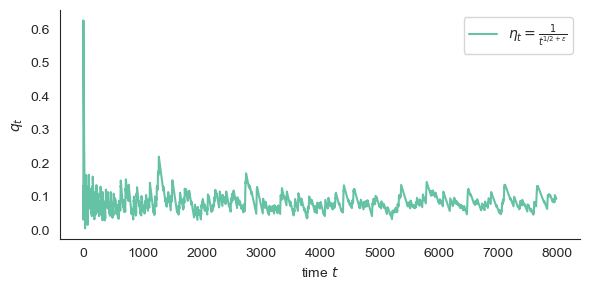

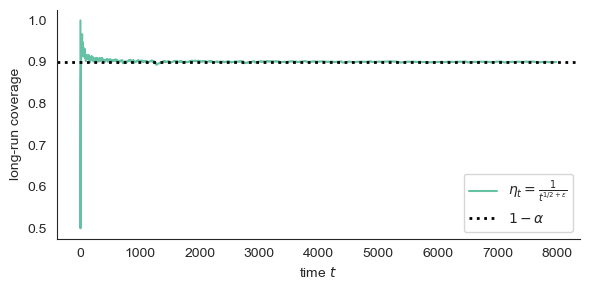

0.08524502235154294


In [705]:
results_data_sp = compute_coverage_metrics(y_true_test[seq_length:], super_preds_scaled, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_data_sp, alpha=0.1, W=1000)
CI_sp_decaying = results_data_sp['q_decaying'] * 2 
print(np.mean(results_data_sp['q_decaying']))

In [706]:
print(f'mean coverage for Super Learner is:', np.mean(results_data_sp['observed_coverages_decaying']))

mean coverage for Super Learner is: 0.8999373825923607


In [707]:
#CI_sa_decaying      = results_jd_sa['q_decaying'] * 2
CI_sarimax_decaying_model1 = results_jd_srm_model1['q_decaying'] * 2
#CI_sarimax_decaying_model2 = results_jd_srm_model2['q_decaying'] * 2
CI_lstm_decaying_model1    = results_jd_lstm3_model1['q_decaying'] * 2
#CI_lstm_decaying_model2    = results_jd_lstm3_model2['q_decaying'] * 2
CI_sp_decaying      = results_data_sp['q_decaying'] * 2  

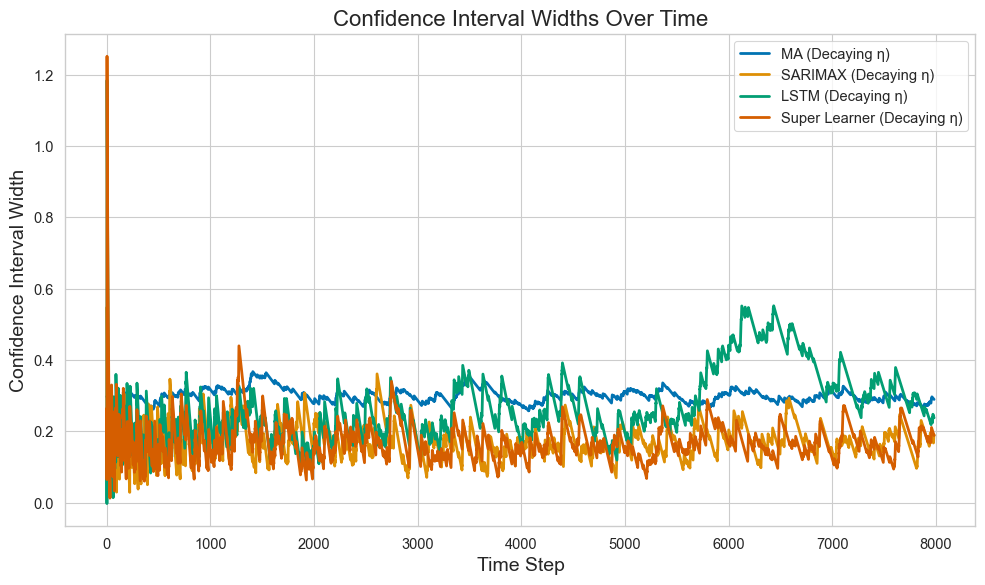

In [722]:
## line comparison plot 
## store important result to one file

import matplotlib.pyplot as plt

# Step 1: Generate a common index (e.g., time steps)
n = len(CI_lstm_decaying_model1)
x = list(range(n))  # n is the number of CI values

# Step 2: Plot setup
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Step 3: Plot each method's CI width as a line
plt.plot(x, CI_ma_decaying[-n:], label='MA (Decaying η)', linewidth=2)
plt.plot(x, CI_sarimax_decaying_model1[-n:], label='SARIMAX (Decaying η)', linewidth=2)
plt.plot(x, CI_lstm_decaying_model1, label='LSTM (Decaying η)', linewidth=2)
plt.plot(x, CI_sp_decaying[-n:], label='Super Learner (Decaying η)', linewidth=2)


# Step 4: Enhance plot readability
plt.title('Confidence Interval Widths Over Time', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Confidence Interval Width', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


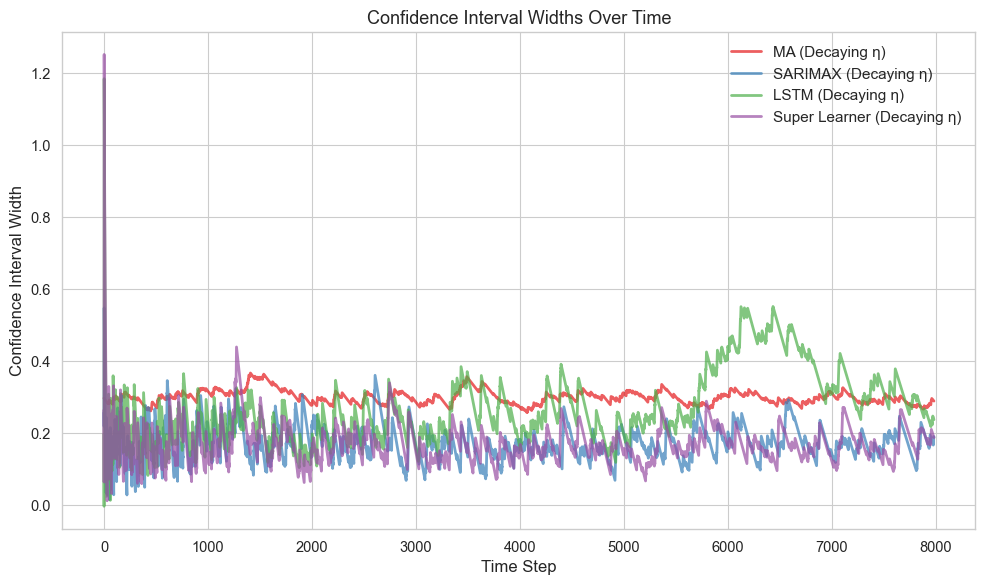

In [728]:
plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set1", 4)

plt.plot(x, CI_ma_decaying[-n:], label='MA (Decaying η)', linewidth=2,alpha = 0.7, color=colors[0])
plt.plot(x, CI_sarimax_decaying_model1[-n:], label='SARIMAX (Decaying η)', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(x, CI_lstm_decaying_model1, label='LSTM (Decaying η)', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(x, CI_sp_decaying[-n:], label='Super Learner (Decaying η)', linewidth=2, alpha = 0.7, color=colors[3])

plt.title('Confidence Interval Widths Over Time', fontsize=13)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("ci_widths_set1.pdf", bbox_inches="tight")
plt.show()

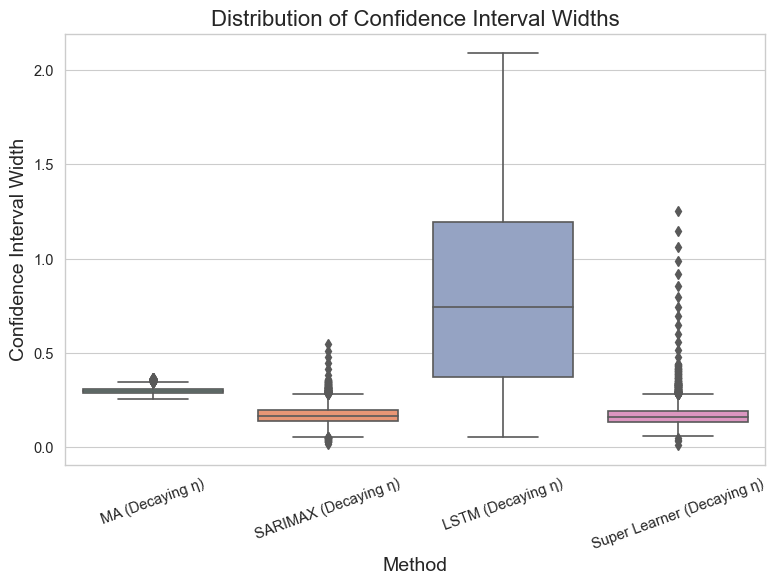

In [895]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "MA (Decaying η)": CI_ma_decaying[-n:],
    "SARIMAX (Decaying η)": CI_sarimax_decaying_model1[-n:],
    "LSTM (Decaying η)": CI_lstm_decaying_model1,
    "Super Learner (Decaying η)": CI_sp_decaying[-n:]
}

# Step 2: Convert to long-format DataFrame (easier for seaborn)
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Create box plot
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
sns.boxplot(x="Method", y="CI Width", data=df_long, palette="Set2")

# Step 4: Enhance readability
plt.title("Distribution of Confidence Interval Widths", fontsize=16)
plt.xlabel("Method", fontsize=14)
plt.ylabel("Confidence Interval Width", fontsize=14)
plt.xticks(rotation=20)  # rotate labels if too long
plt.tight_layout()
plt.show()

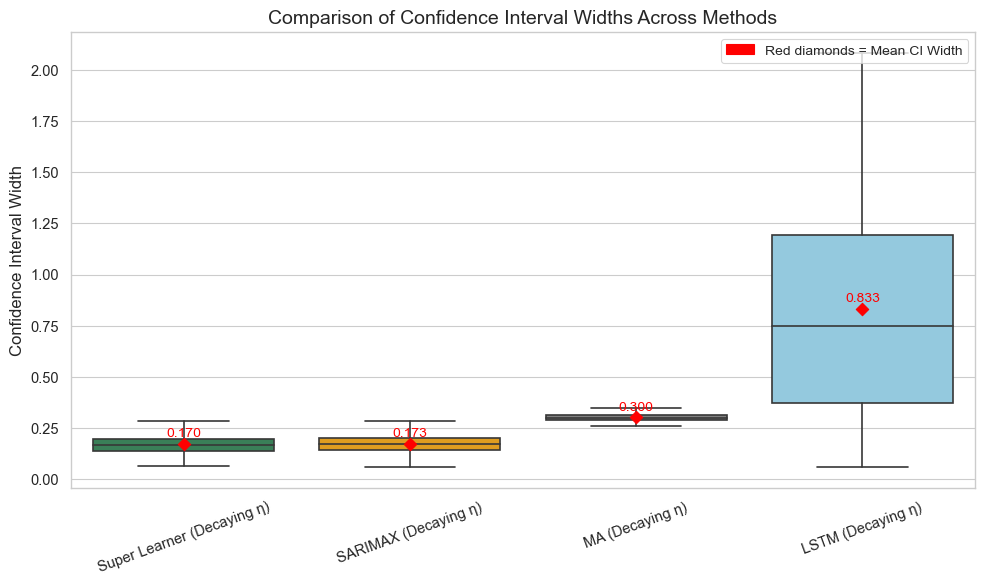

In [1182]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "MA (Decaying η)": CI_ma_decaying[-n:],
    "SARIMAX (Decaying η)": CI_sarimax_decaying_model1[-n:],
    "LSTM (Decaying η)": CI_lstm_decaying_model1,
    "Super Learner (Decaying η)": CI_sp_decaying[-n:]
}

# Step 2: Convert to long-format DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Define custom order by median CI width
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = {
    "MA (Decaying η)": "gray",
    "SARIMAX (Decaying η)": "orange",
    "LSTM (Decaying η)": "skyblue",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

# Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=10, color="red")

# Step 5: Add custom legend entry for red mean points
mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=10, frameon=True)

# Step 6: Enhance readability
plt.title("Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### COMA 

###### Adahedge 

Mean deterministic coverage: 0.8996869129618034
Mean randomized coverage: 0.8996869129618034
Mean CI width — COMA (det): 0.17270140037471873
Mean CI width — COMA (rand): 0.1724848017383047
Mean CI width — Super Learner: 0.17049004470308587


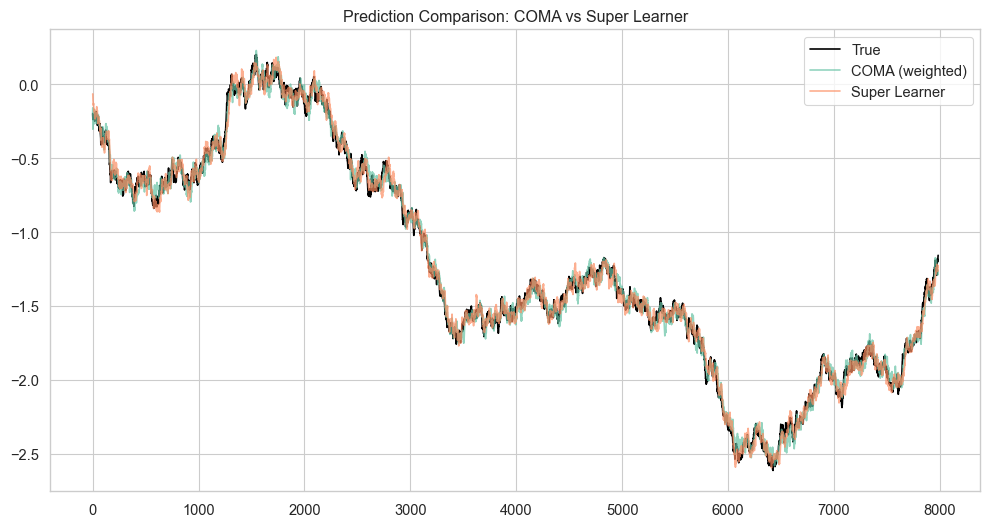

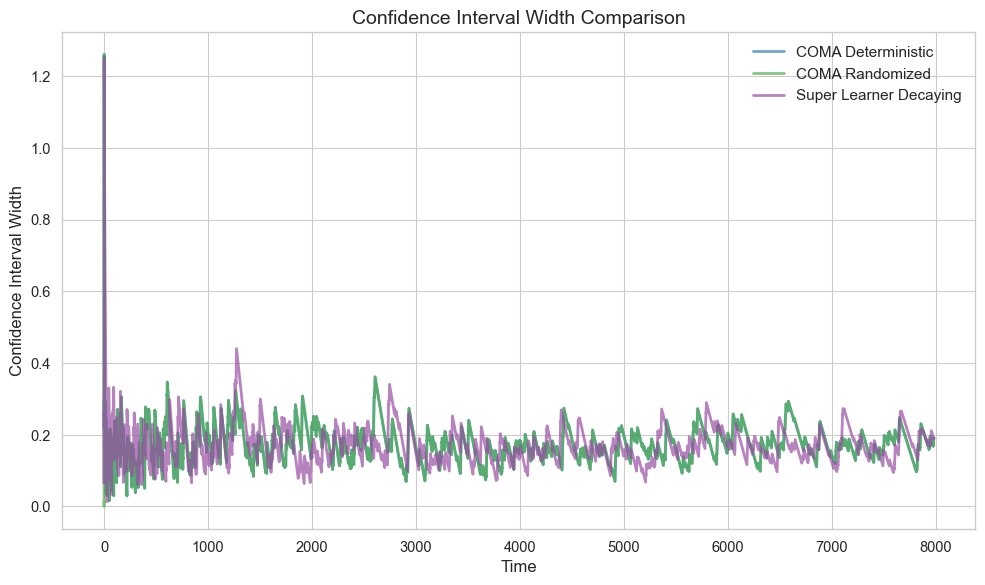

In [1217]:
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(results_jd_sa['q_decaying']),
    len(results_jd_srm_model1['q_decaying']),
    #len(results_jd_srm_model2['q_decaying']),
    len(results_jd_lstm3_model1['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(CI_sp_decaying),
    len(y_true_test)
)

# --- Step 2: CI half-widths (2 * q_decaying) ---
ci_matrix = np.column_stack([
    CI_ma_decaying[-min_len:],
    CI_sarimax_decaying_model1[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model1[-min_len:],
    #2 * results_jd_lstm3_model2['q_decaying'][:min_len]

])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_ma = np.column_stack([
    yhat_sa_jd[-min_len:] 
    - results_jd_sa['q_decaying'][-min_len:],
    yhat_sa_jd[-min_len:] 
    + results_jd_sa['q_decaying'][-min_len:]
])

intervals_sarimax_model1 = np.column_stack([
    Yhat_jd_srm_model1[-min_len:] 
    - results_jd_srm_model1['q_decaying'][-min_len:],
    Yhat_jd_srm_model1[-min_len:] 
    + results_jd_srm_model1['q_decaying'][-min_len:]
])

intervals_lstm1 = np.column_stack([
    y_pred_lstm_sim3_model1[-min_len:] - results_jd_lstm3_model1['q_decaying'][-min_len:],
    y_pred_lstm_sim3_model1[-min_len:] + results_jd_lstm3_model1['q_decaying'][-min_len:]
])


intervals_list_plain = [intervals_ma, intervals_sarimax_model1, intervals_lstm1]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m   = result_plain["pi_m"]
pi_wm  = result_plain["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sp_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    yhat_sa_jd[-min_len:],
    Yhat_jd_srm_model1[-min_len:],
    y_pred_lstm_sim3_model1[-min_len:]
])
# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds_scaled[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot ---
plt.figure(figsize=(10, 6))

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

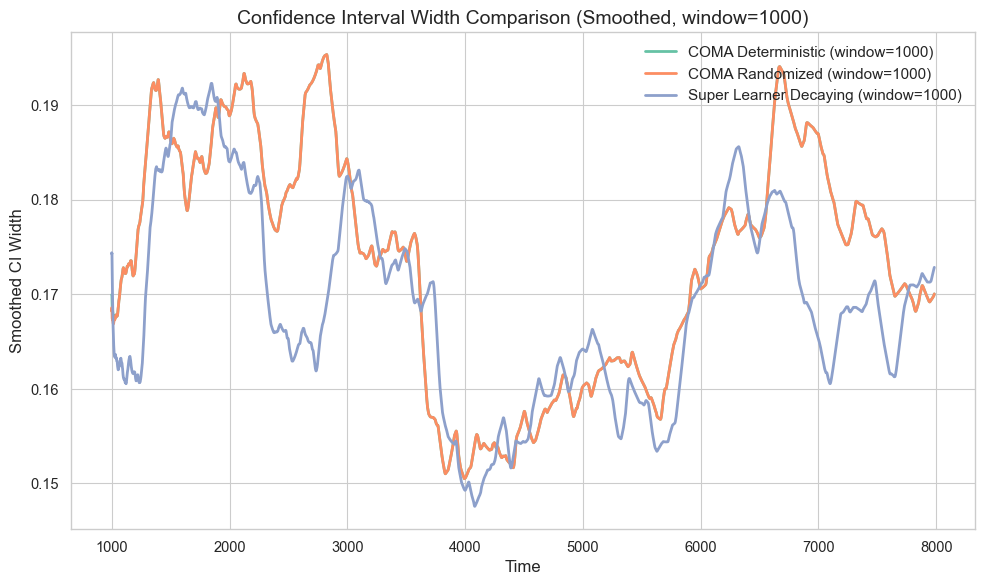

In [1218]:
window = 1000  # try 50, 100, 200, 500
plt.figure(figsize=(10, 6))

plt.plot(pd.Series(coma_width_det).rolling(window).mean(), 
         label=f'COMA Deterministic (window={window})', linewidth=2)
plt.plot(pd.Series(coma_width_rand).rolling(window).mean(), 
         label=f'COMA Randomized (window={window})', linewidth=2)
plt.plot(pd.Series(CI_super_decaying).rolling(window).mean(), 
         label=f'Super Learner Decaying (window={window})', linewidth=2)

plt.xlabel('Time', fontsize=12)
plt.ylabel('Smoothed CI Width', fontsize=12)
plt.title(f'Confidence Interval Width Comparison (Smoothed, window={window})', fontsize=14)
plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

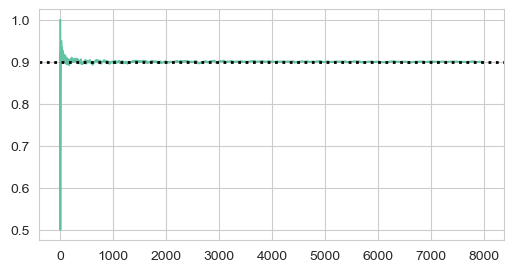

In [711]:
coma_coverage = np.cumsum(result_plain['m_cov']) / (np.arange(len(result_plain['m_cov'])) + 1)
plt.figure(figsize=(6, 3))
plt.plot(range(len(result_plain['m_cov'])), coma_coverage, label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
#plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
plt.axhline(y= (1 - 0.1), linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')


Mean deterministic coverage: 0.8894176581089542
Mean randomized coverage: 0.8840325610519725
Mean CI width — COMA (det): 0.17270140037471873
Mean CI width — COMA (rand): 0.1725462798091158
Mean CI width — COMA (det) + SL: 0.16911728741666956
Mean CI width — COMA (rand) + SL: 0.16543365462415435


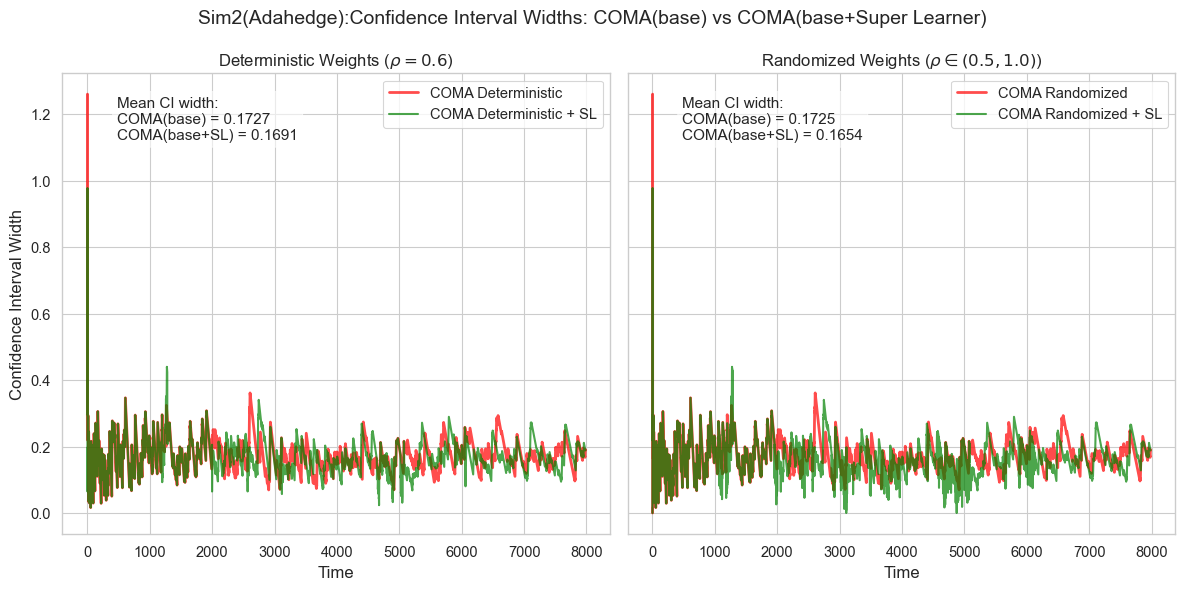

In [1219]:

min_len = min(
    len(results_jd_sa['q_decaying']),
    len(results_jd_srm_model1['q_decaying']),
    len(results_jd_lstm3_model1['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(results_data_sp['q_decaying']),
    len(y_true_test)
)

ci_matrix_sl = np.column_stack([
    CI_ma_decaying[-min_len:],
    CI_sarimax_decaying_model1[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model1[-min_len:],
    CI_sp_decaying[-min_len:]
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)

intervals_ma = np.column_stack([
    yhat_sa_jd[-min_len:] 
    - results_jd_sa['q_decaying'][-min_len:],
    yhat_sa_jd[-min_len:] 
    + results_jd_sa['q_decaying'][-min_len:]
])

intervals_sarimax_model1 = np.column_stack([
    Yhat_jd_srm_model1[-min_len:] 
    - results_jd_srm_model1['q_decaying'][-min_len:],
    Yhat_jd_srm_model1[-min_len:] 
    + results_jd_srm_model1['q_decaying'][-min_len:]
])


intervals_lstm1 = np.column_stack([
    y_pred_lstm_sim3_model1[-min_len:] - results_jd_lstm3_model1['q_decaying'][-min_len:],
    y_pred_lstm_sim3_model1[-min_len:] + results_jd_lstm3_model1['q_decaying'][-min_len:]
])



intervals_sp = np.column_stack([
    super_preds_scaled[-min_len:] - results_data_sp['q_decaying'][-min_len:],
    super_preds_scaled[-min_len:] + results_data_sp['q_decaying'][-min_len:]
])

# --- Step 4: Pack intervals + weights ---
intervals_list_sl = [intervals_ma, intervals_sarimax_model1, intervals_lstm1, intervals_sp]
weights_sl = adahedAlg_sl["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)

print("Mean deterministic coverage:", result_sl["mean_m_cov"])
print("Mean randomized coverage:", result_sl["mean_wm_cov"])


intervals_list_plain = [intervals_ma, intervals_sarimax_model1, intervals_lstm1]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)
# --- Step 7: Compute widths ---
pi_m_plain   = result_plain["pi_m"]
pi_wm_plain  = result_plain["pi_wm"]
coma_width_det  = np.array([loss_fun(ci) for ci in pi_m_plain])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_plain])
# --- Step 7: Compute widths ---
pi_m_sl   = result_sl["pi_m"]
pi_wm_sl  = result_sl["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.6$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Add mean values annotation
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Add mean values annotation
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2(Adahedge):Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()

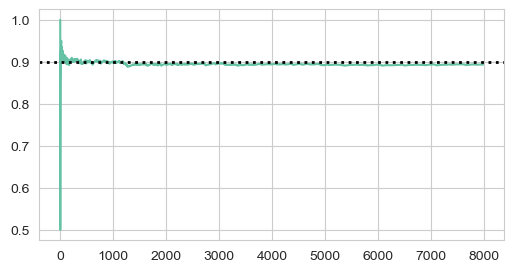

In [712]:
coma_coverag_sl = np.cumsum(result_sl['m_cov']) / (np.arange(len(result_sl['m_cov'])) + 1)
plt.figure(figsize=(6, 3))
plt.plot(range(len(result_sl['m_cov'])), coma_coverag_sl, label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
#plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
plt.axhline(y= (1 - 0.1), linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')

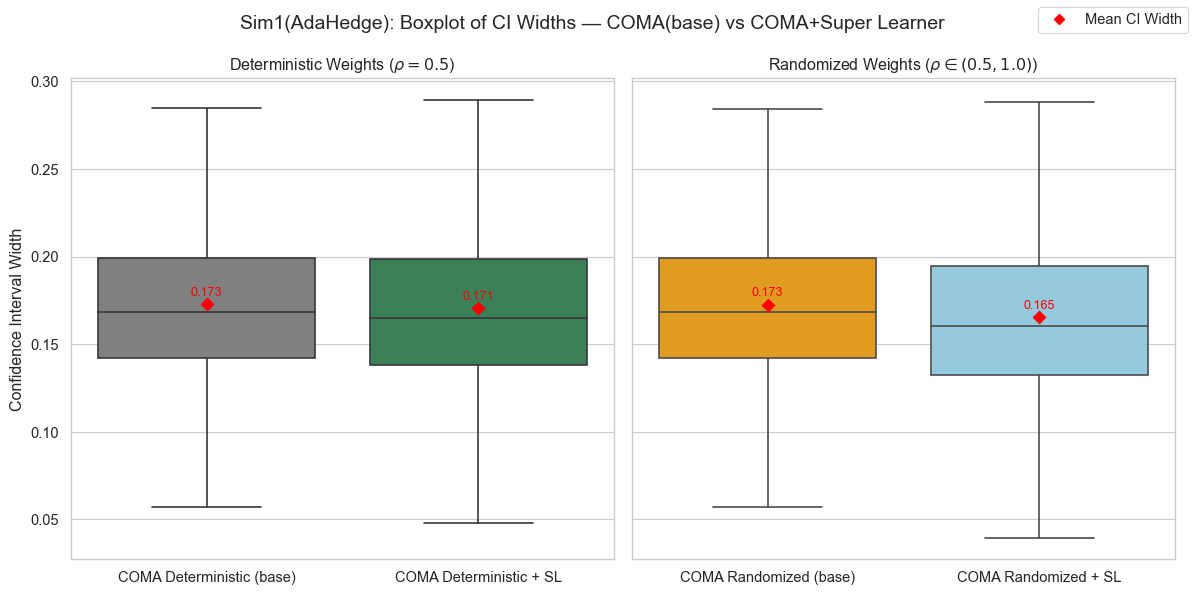

In [1215]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Put data into long format
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic + SL": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized + SL": coma_width_rand_sl
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 2: Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic + SL"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized + SL"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.set_style("whitegrid")
palette = {"COMA Deterministic (base)": "gray",
           "COMA Deterministic + SL": "seagreen",
           "COMA Randomized (base)": "orange",
           "COMA Randomized + SL": "skyblue"}

# --- Deterministic subplot ---
ax0 = sns.boxplot(x="Method", y="CI Width", 
                  data=df_long[df_long["Method"].isin(det_methods)],
                  order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = df_long[df_long["Method"].isin(det_methods)].groupby("Method")["CI Width"].mean()
for i, method in enumerate(det_methods):
    ax0.scatter(i, means_det[method], color="red", marker="D", s=40, zorder=3, 
                label="Mean CI Width" if i==0 else "")
    ax0.text(i, means_det[method]+0.005, f"{means_det[method]:.3f}", 
             ha="center", fontsize=9, color="red")

ax0.set_title("Deterministic Weights ($\\rho=0.5$)")
ax0.set_xlabel("")
ax0.set_ylabel("Confidence Interval Width")

# --- Randomized subplot ---
ax1 = sns.boxplot(x="Method", y="CI Width", 
                  data=df_long[df_long["Method"].isin(rand_methods)],
                  order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = df_long[df_long["Method"].isin(rand_methods)].groupby("Method")["CI Width"].mean()
for i, method in enumerate(rand_methods):
    ax1.scatter(i, means_rand[method], color="red", marker="D", s=40, zorder=3)
    ax1.text(i, means_rand[method]+0.005, f"{means_rand[method]:.3f}", 
             ha="center", fontsize=9, color="red")

ax1.set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)")
ax1.set_xlabel("")
ax1.set_ylabel("")

# Legend for red diamonds
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc="upper right")

plt.suptitle("Sim1(AdaHedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

###### Hedge 

In [1171]:
rho_rand = np.random.uniform(0.5, 1.0)
print(rho_rand)

0.5823949048598036


In [1186]:
intervals_list_plain.shape

AttributeError: 'list' object has no attribute 'shape'

Mean deterministic coverage (COMA base): 0.8999373825923607
Mean randomized coverage (COMA base): 0.8995616781465248
Mean deterministic coverage (COMA+SL): 0.8931747025673137
Mean randomized coverage (COMA+SL): 0.8807764558547276
Mean CI width — COMA(base, det): 0.17293873408289506
Mean CI width — COMA(base, rand): 0.17274773486045722
Mean CI width — COMA(base+SL, det): 0.17103434228041325
Mean CI width — COMA(base+SL, rand): 0.16327693024925763


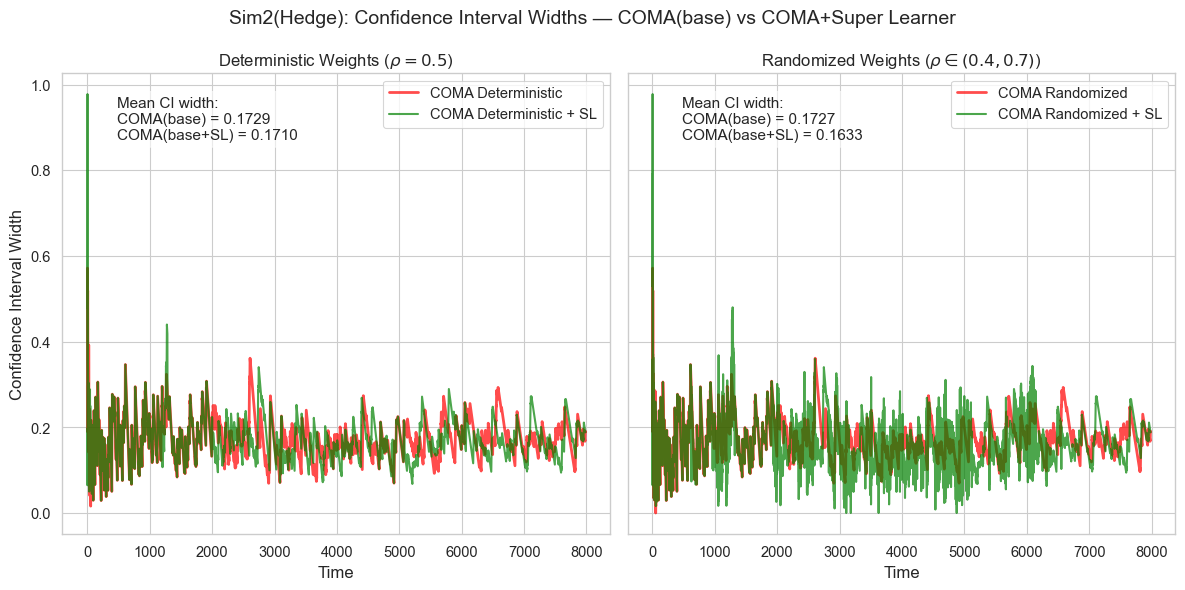

In [1220]:
# --- Step 1: Run Hedge separately for base (3 experts) and base+SL (4 experts) ---
hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape

# Ensure alignment
min_len = min(len(y_true_test), N_base, N_sl)
y_test_aligned = y_true_test[-min_len:]

# --- Step 2: Preallocate ---
pi_m_base, pi_wm_base = [], []
pi_m_sl, pi_wm_sl     = [], []

m_cov_base = np.full(min_len, np.nan)
wm_cov_base = np.full(min_len, np.nan)
m_cov_sl   = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

# --- Step 3: Loop over time ---
for i in range(min_len):
    # --- Sample ONE rho per step and reuse for both base and base+SL ---
    rho_rand = np.random.uniform(0.4,0.7)

    # --- Base (3 experts) ---
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(3)])
    maj_int_base = majority_vote(conf_base, w=weights_base[i], rho=0.5)
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=rho_rand)

    pi_m_base.append(maj_int_base)
    pi_wm_base.append(wmaj_int_base)
    m_cov_base[i]  = covr_fun(maj_int_base, y_test_aligned[i])
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # --- Base+SL (4 experts) ---
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(4)])
    maj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=0.5)
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=rho_rand)  # same rho_rand

    pi_m_sl.append(maj_int_sl)
    pi_wm_sl.append(wmaj_int_sl)
    m_cov_sl[i]  = covr_fun(maj_int_sl, y_test_aligned[i])
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])

# --- Step 4: Compute widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 5: Summaries ---
print("Mean deterministic coverage (COMA base):", np.nanmean(m_cov_base))
print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean deterministic coverage (COMA+SL):", np.nanmean(m_cov_sl))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# --- Step 7: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.4,0.7)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2(Hedge): Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

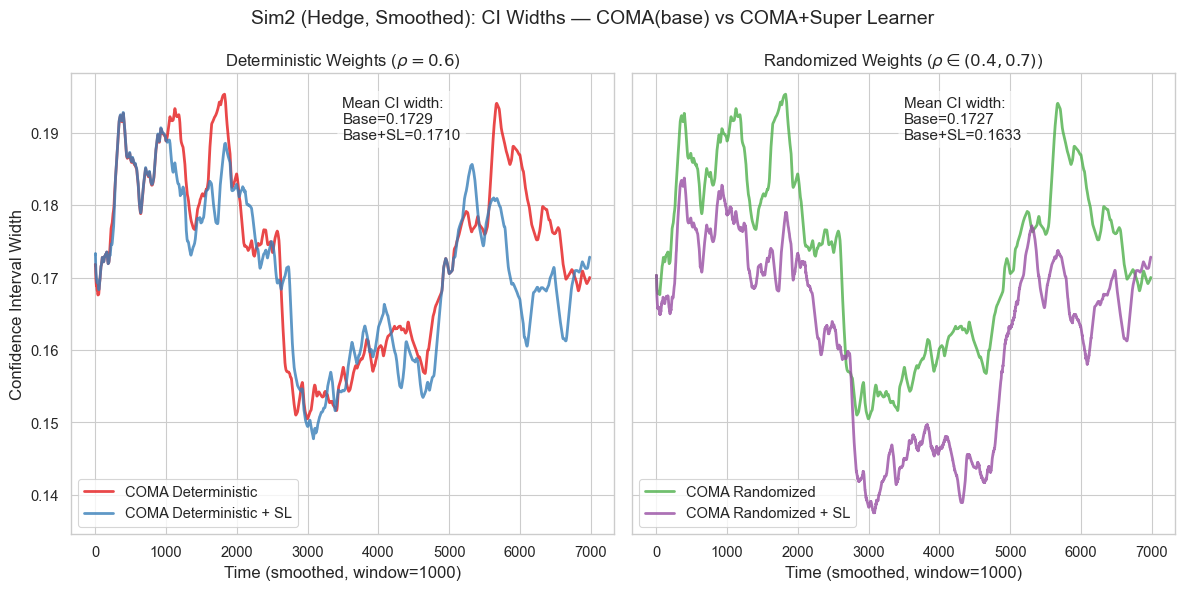

In [1225]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper function for smoothing ---
def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

# --- Step 7: Subplot comparison (smoothed) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

window = 1000  # <-- adjust this for stronger/weaker smoothing

# --- Deterministic subplot ---
axes[0].plot(smooth_series(coma_width_det, window), 
             label='COMA Deterministic', linewidth=2, alpha=0.8, color=colors[0])
axes[0].plot(smooth_series(coma_width_det_sl, window), 
             label='COMA Deterministic + SL', linewidth=2, alpha=0.8, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.6$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.5, 0.95,
             f"Mean CI width:\nBase={mean_det:.4f}\nBase+SL={mean_det_sl:.4f}",
             transform=axes[0].transAxes, fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(smooth_series(coma_width_rand, window), 
             label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(smooth_series(coma_width_rand_sl, window), 
             label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.4,0.7)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.5, 0.95,
             f"Mean CI width:\nBase={mean_rand:.4f}\nBase+SL={mean_rand_sl:.4f}",
             transform=axes[1].transAxes, fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2 (Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

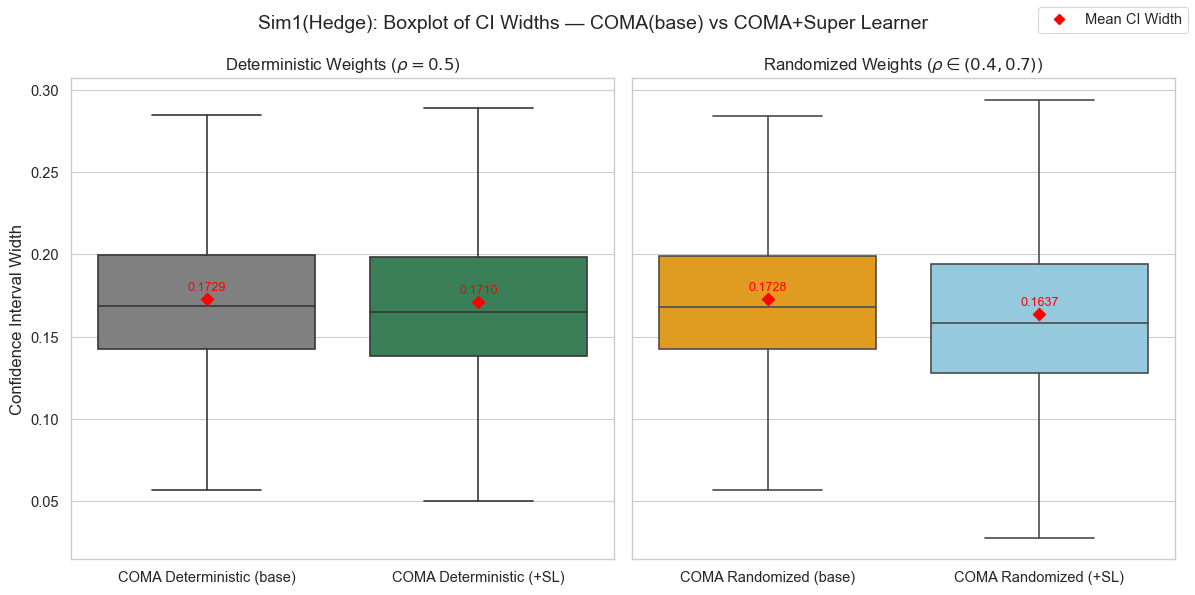

In [1200]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Step 1: Organize all data into one dictionary ---
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

# Convert to DataFrame (long format)
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic (+SL)"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

# Custom palette (optional)
palette = {
    "COMA Deterministic (base)": "gray",
    "COMA Deterministic (+SL)": "seagreen",
    "COMA Randomized (base)": "orange",
    "COMA Randomized (+SL)": "skyblue"
}

# --- Step 2: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.set_style("whitegrid")

# --- Deterministic subplot ---
ax0 = sns.boxplot(x="Method", y="CI Width",
                  data=df_long[df_long["Method"].isin(det_methods)],
                  order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = df_long[df_long["Method"].isin(det_methods)].groupby("Method")["CI Width"].mean().reindex(det_methods)
for i, method in enumerate(det_methods):
    ax0.scatter(i, means_det[method], color="red", marker="D", s=40, zorder=3,
                label="Mean CI Width" if i == 0 else "")
    ax0.text(i, means_det[method] + 0.005, f"{means_det[method]:.4f}",
             ha="center", fontsize=9, color="red")

ax0.set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
ax0.set_xlabel("")
ax0.set_ylabel("Confidence Interval Width", fontsize=12)

# --- Randomized subplot ---
ax1 = sns.boxplot(x="Method", y="CI Width",
                  data=df_long[df_long["Method"].isin(rand_methods)],
                  order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = df_long[df_long["Method"].isin(rand_methods)].groupby("Method")["CI Width"].mean().reindex(rand_methods)
for i, method in enumerate(rand_methods):
    ax1.scatter(i, means_rand[method], color="red", marker="D", s=40, zorder=3)
    ax1.text(i, means_rand[method] + 0.005, f"{means_rand[method]:.4f}",
             ha="center", fontsize=9, color="red")

ax1.set_title("Randomized Weights ($\\rho \\in (0.4, 0.7)$)", fontsize=12)
ax1.set_xlabel("")
ax1.set_ylabel("")

# Legend for red diamonds
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc="upper right")

# Global title
plt.suptitle("Sim1(Hedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

### sigma = 0.5, lamb = 0.15, mu_j = -0.1, sigma_j = 0.35
Strong continuous volatility, jumps still moderate

#### Visualization

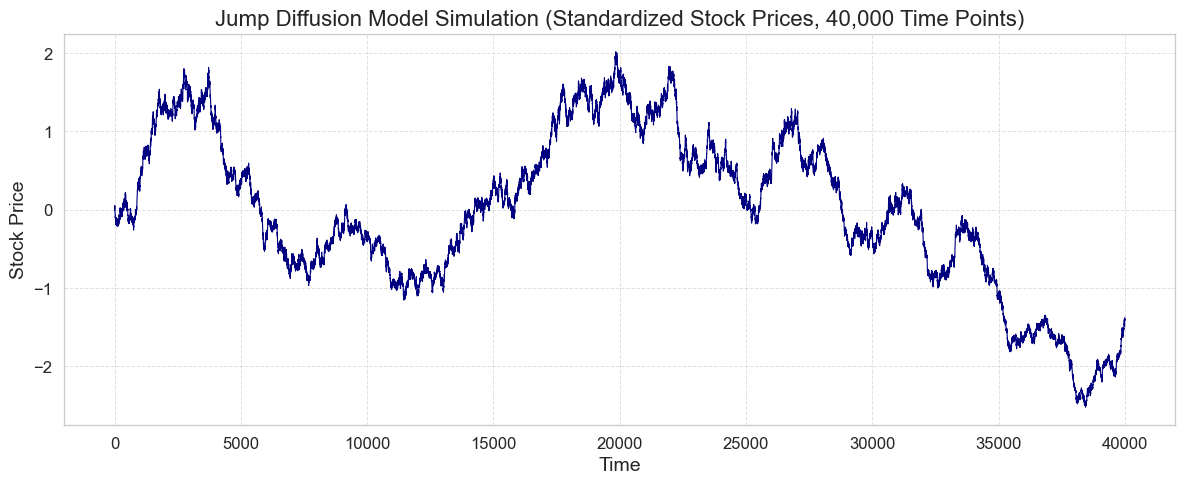

In [1115]:
# Set seed for reproducibility
np.random.seed(42)

# Parameters
S0 = 100         # initial stock price
mu = 0.05         # neutral drift, no strong trend
sigma = 0.4     # higher volatility (2.5x baseline)
lamb = 0.15      # more frequent jumps (vs 0.1 baseline)
mu_j = -0.3      # same mean jump size
sigma_j = 0.35   # slightly larger variability in jump size
T = 1.0
N = 40000
dt = T / N

# Time grid
t = np.arange(N)

# Brownian increments
dW = np.random.normal(0, np.sqrt(dt), N)

# Poisson jump component
N_jumps = np.random.poisson(lamb * dt, N)  # 0 or 1 jumps per step
J = np.random.normal(mu_j, sigma_j, N)     # jump sizes
jump_component = (np.exp(J) - 1) * N_jumps

# Initialize price path
S = np.zeros(N)
S[0] = S0

# Simulate path
for i in range(1, N):
    S[i] = S[i-1] * (1 + mu * dt + sigma * dW[i] + jump_component[i])

scaler = StandardScaler()
S_sd2 = scaler.fit_transform(S.reshape(-1, 1)).flatten()


data_jd_sd2 = pd.DataFrame({'x': t, 'y': S_sd2})
# y_observed = y + noise 
# y_true 

# Plot
plt.figure(figsize=(12, 5))

# Plot with publication style
plt.plot(data_jd_sd2['x'], data_jd_sd2['y'], color="navy", linewidth=0.8)

# Titles and labels
plt.title('Jump Diffusion Model Simulation (Standardized Stock Prices, 40,000 Time Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid & frame
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)

# Clean frame
plt.tight_layout()
plt.show()

#### Train-Test Split

In [1046]:
# Train-test split 

noise = np.random.normal(0, 0.2, size=S_sd2.shape)
y_observed2 = data_jd_sd2['y'] + noise 
train_size2 = int(0.8 * len(y_observed2))
test_size2 = int(0.2 * len(y_observed2))

y_train_sim2 = y_observed2[:train_size2]
y_true2 = data_jd_sd2['y'].to_numpy()
y_true_test2 = data_jd_sd2['y'].to_numpy()[train_size2:] 


print(f"Train dataset shape: {y_train_sim2.shape}, Test dataset shape: {y_true_test2.shape}")



Train dataset shape: (32000,), Test dataset shape: (8000,)


#### Base Learners

##### Smooth Array 

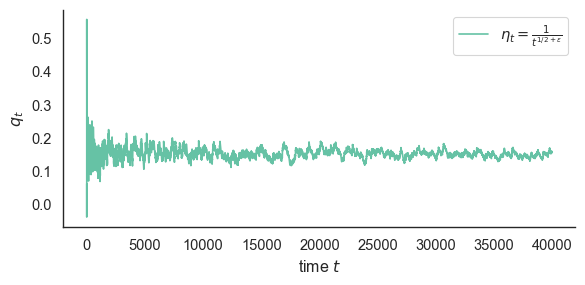

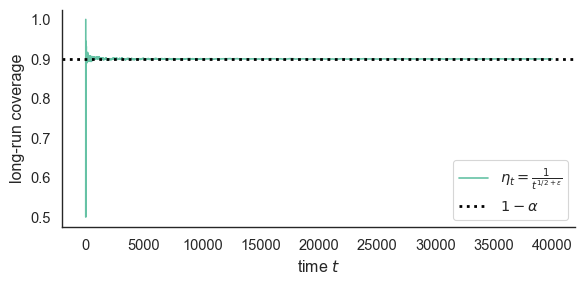

In [1048]:
# Get predictions
yhat_sa_jd2 = causal_ma(y_observed2.to_numpy(), w=5)

yhat_sa_jd2 = np.asarray(yhat_sa_jd2, dtype=float)

valid = ~np.isnan(yhat_sa_jd2)
y_true_jd2 = y_true2[valid]
yhat_sa_jd2 = yhat_sa_jd2[valid]
# Compute coverage
results_jd_sa2 = compute_coverage_metrics(
    y_true_jd2,
    yhat_sa_jd2,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_jd_sa2, alpha=0.1, W=1000)
CI_ma_decaying2 = results_jd_sa2['q_decaying'] * 2

In [1049]:
print(f'mean coverage for moving average is:', np.mean(results_jd_sa2['observed_coverages_decaying']))

mean coverage for moving average is: 0.899962495311914


##### SARIMAX 

In [1003]:
best_cfg, best_score = sarimax_grid_search(
    y_observed2,           # pd.Series (observed)
    y_true_test2,          # ground-truth test target (e.g., true series[train_size:])
    train_size2,
    p_values=[1,2],
    d_values=[0,1,2],
    q_values=[0,1,2]
)

print(f"Best SARIMAX parameters: p={best_cfg[0]}, d={best_cfg[1]}, q={best_cfg[2]}")
print(f"Best RMSE: {best_score:.4f}")

100%|██████████| 8000/8000 [08:57<00:00, 14.88it/s]


SARIMAX(1,0,0) RMSE=0.2052


100%|██████████| 8000/8000 [09:38<00:00, 13.83it/s]


SARIMAX(1,0,1) RMSE=0.0449


100%|██████████| 8000/8000 [10:46<00:00, 12.38it/s] 


...

100%|██████████| 8000/8000 [10:14<00:00, 13.02it/s]


SARIMAX(1,1,1) RMSE=0.0449


  1%|▏         | 108/8000 [00:07<08:57, 14.69it/s]


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/victoria/anaconda3/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/3g/vqq7m4xs16xcb02w786r50pw0000gn/T/ipykernel_45583/533342730.py", line 1, in <module>
    best_cfg, best_score = sarimax_grid_search(
                           ^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/3g/vqq7m4xs16xcb02w786r50pw0000gn/T/ipykernel_45583/4036718706.py", line 54, in sarimax_grid_search
    preds = rolling_sarimax_forecast(observed_data, train_size, p, d, q)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/3g/vqq7m4xs16xcb02w786r50pw0000gn/T/ipykernel_45583/1974435216.py", line 31, in rolling_sarimax_forecast
    sarimax_model = sarimax_model.append([new_obs], refit=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/victoria/anaconda3/lib/python3.11/site-packages/st

100%|██████████| 8000/8000 [10:03<00:00, 13.26it/s]


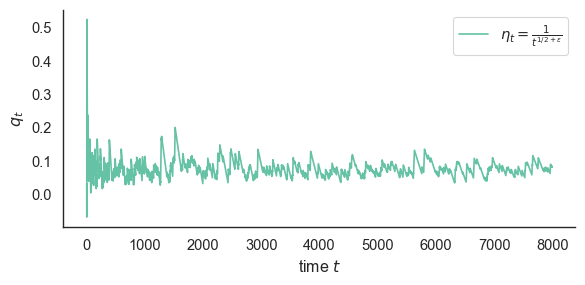

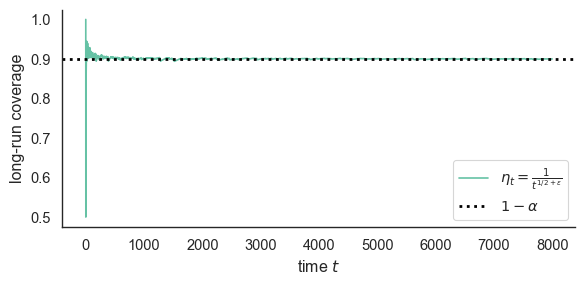

In [1050]:
Yhat_jd_srm2= rolling_sarimax_forecast(y_observed2, train_size2, p=1, d=0, q=2)
Y_jd_srm2 = np.array(y_true_test2)
results_jd_srm2 = compute_coverage_metrics(Y_jd_srm2, Yhat_jd_srm2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_srm2, alpha=0.1, W=1000)
CI_sarimax_decaying2 = results_jd_srm2['q_decaying'] * 2 

In [1005]:
print(f'mean coverage for SARIMAX is:', np.mean(results_jd_srm2['observed_coverages_decaying']))

mean coverage for SARIMAX is: 0.9


##### LSTM

###### Grid Search

In [1051]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from sklearn.model_selection import train_test_split

seq_length = 15
X_train, X_test, y_train, y_test = create_sequences(y_observed2, seq_length, train_ratio = 0.8)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, shuffle=False
)
# --- Define Tunable Model ---
def build_model(hp):
    model = Sequential()
    
    # Tune LSTM units
    hp_units_1 = hp.Int('units_1', min_value=64, max_value=256, step=32)
    hp_units_2 = hp.Int('units_2', min_value=32, max_value=128, step=32)
    
    # Tune dropout
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    
    # Tune learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
    
    model.add(LSTM(hp_units_1, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)))
    model.add(Dropout(hp_dropout))
    model.add(LSTM(hp_units_2, activation='tanh'))
    model.add(Dropout(hp_dropout))
    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    return model

# --- Tuner Setup (overwrite=True ensures fresh search) ---
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=15,              # more trials = better search
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='stock_prediction',
    overwrite=True              # ensures it restarts from scratch
)

# Grid search 
print("Starting hyperparameter search...")
tuner.search(
    X_train, y_train,
    epochs=20,                  # longer, but early stopping will cut short
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# --- Get Best Hyperparameters ---
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n--- Search Complete ---")
print(f"Optimal units in LSTM Layer 1: {best_hps.get('units_1')}")
print(f"Optimal units in LSTM Layer 2: {best_hps.get('units_2')}")
print(f"Optimal dropout rate: {round(best_hps.get('dropout'), 2)}")
print(f"Optimal learning rate: {best_hps.get('learning_rate')}")
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

# This is the epoch where val_loss was lowest
best_epoch = best_trial.best_step
print("Best epoch found:", best_epoch)
# --- Train Final Model ---
print("\nTraining the final model with the best hyperparameters...")

Trial 15 Complete [00h 05m 03s]
val_loss: 0.04318057745695114

Best val_loss So Far: 0.04301104694604874
Total elapsed time: 00h 49m 18s

--- Search Complete ---
Optimal units in LSTM Layer 1: 256
Optimal units in LSTM Layer 2: 64
Optimal dropout rate: 0.4
Optimal learning rate: 0.0001
Best epoch found: 15

Training the final model with the best hyperparameters...


/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


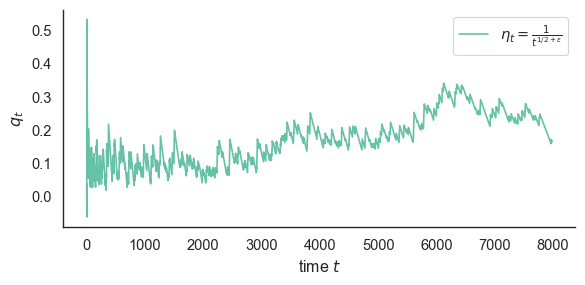

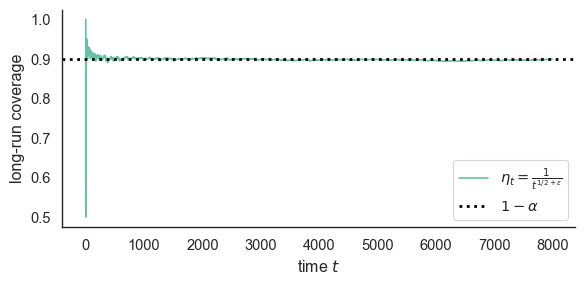

0.1720651420483105


In [1073]:
from tensorflow.keras.layers import Dropout


from tensorflow.keras.layers import Dropout


seq_length = 15

X_train, X_test, y_train, y_test = create_sequences(y_observed2, seq_length, train_ratio = 0.8)

model2 = Sequential([
    LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.4),
    LSTM(64, activation='tanh'),
    Dropout(0.4),
    Dense(1)
])


model2.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')
history = model2.fit(X_train, y_train, epochs=15, batch_size=16, verbose = 0)
y_pred_lstm_sim2 = model2.predict(X_test).flatten()


results_jd_lstm2 = compute_coverage_metrics(y_true_test2[seq_length:], y_pred_lstm_sim2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm2, alpha=0.1, W=1000)
print(np.mean(results_jd_lstm2['q_decaying']))
CI_lstm_decaying2 = results_jd_lstm2['q_decaying'] * 2

In [1074]:
print(f'mean coverage for LSTM is:', np.mean(results_jd_lstm2['observed_coverages_decaying']))

mean coverage for LSTM is: 0.8996869129618034


### Model Aggregation

#### Super Learner

In [1075]:
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# --- Parameters ---
seq_length = 15
n_splits = 5
sarimax_configs = [(1,0,2)]
lstm_configs = [ {"units1": 256, "units2": 64, "dropout": 0.4}]
ma_windows = [5]

data_scaled = y_observed2.values.astype(float)
n_total = len(data_scaled)
train_size = int(0.8 * n_total)

# Number of base learners
n_learners = len(ma_windows) + len(sarimax_configs) + len(lstm_configs)

meta_features = np.full((train_size - seq_length, n_learners), np.nan)
meta_targets  = y_true[seq_length:train_size]
train_data_scaled = data_scaled[:train_size]

tscv = TimeSeriesSplit(n_splits=n_splits)

X_all, _, y_all, _ = create_sequences(data_scaled, seq_length, train_ratio=0.8)
for fold, (train_idx, val_idx) in enumerate(tscv.split(train_data_scaled)):
    col = 0

    # ensure val_idx has only usable points
    mask = val_idx >= seq_length
    if not np.any(mask):
        continue
    val_idx_eff = val_idx[mask]
    rows = val_idx_eff - seq_length

    # SARIMAX
    for (p,d,q) in sarimax_configs:
        sarimax_preds = rolling_sarimax_forecast(
            pd.Series(train_data_scaled[:val_idx[-1]+1]), len(train_idx), p, d, q
        )[-len(val_idx):]
        meta_features[rows, col] = sarimax_preds[mask]
        col += 1

    # MA
    for w in ma_windows:
        ma_smoothed = causal_ma(train_data_scaled[:val_idx[-1]+1], w)
        meta_features[rows, col] = ma_smoothed[val_idx_eff]
        col += 1

    # LSTM
    tr_rows = train_idx[train_idx >= seq_length] - seq_length
    va_rows = val_idx_eff - seq_length

    X_tr, y_tr = X_all[tr_rows], y_all[tr_rows]
    X_va, y_va = X_all[va_rows], y_all[va_rows]

    for config in lstm_configs:
        lstm_model = Sequential([
            LSTM(config["units1"], activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
            Dropout(config["dropout"]),
            LSTM(config["units2"], activation='tanh'),
            Dropout(config["dropout"]),
            Dense(1)
        ])
        lstm_model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error' )
        lstm_model.fit(X_tr, y_tr, epochs=15, batch_size=16, verbose=0)
        lstm_preds = lstm_model.predict(X_va).flatten()
        meta_features[rows, col] = lstm_preds
        col += 1

# drop any rows that remain NaN (early folds may be partially masked)
valid_rows = ~np.isnan(meta_features).any(axis=1)
X_meta = meta_features[valid_rows]
y_meta = meta_targets[valid_rows]

def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    """
    Optimize convex weights with MSE loss.
    Optionally add L1 (alpha1) and L2 (alpha2) regularization.
    """
    init_phi = np.ones(X.shape[1]) / X.shape[1]

    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2

    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]

    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

meta_weights = optimize_weights(X_meta, y_meta, alpha1=0, alpha2=0)
print("Meta-learner weights:", meta_weights)

# --- Final training on full data for test-time preds ---
# Build test stacks aligned to y_test_full (sequence-based)
X_train_full, X_test_full, y_train_full, y_test_full = create_sequences(data_scaled, seq_length, train_ratio = 0.8)
n_test = len(y_test_full)

sarimax_full_preds = []
for (p,d,q) in sarimax_configs:
    sarimax_preds_all = rolling_sarimax_forecast(pd.Series(data_scaled), train_size, p, d, q)
    sarimax_full_preds.append(sarimax_preds_all[-n_test:])

ma_full = []
for w in ma_windows:
    ma_smoothed_all = causal_ma(data_scaled, w)
    ma_full.append(ma_smoothed_all[-n_test:])

lstm_full_preds = []
for config in lstm_configs:
    lstm_model_full = Sequential([
        LSTM(config["units1"], activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(config["dropout"]),
        LSTM(config["units2"], activation='tanh'),
        Dropout(config["dropout"]),
        Dense(1)
    ])
    lstm_model_full.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')
    lstm_model_full.fit(X_train_full, y_train_full, epochs=15, batch_size=16, verbose=0)
    preds = lstm_model_full.predict(X_test_full).flatten()
    lstm_full_preds.append(preds)

X_test_meta = np.column_stack(
    [arr for arr in sarimax_full_preds]+
    ma_full+
    lstm_full_preds
)
super_preds_scaled2 = X_test_meta @ meta_weights

100%|██████████| 5333/5333 [01:36<00:00, 55.24it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


100%|██████████| 5333/5333 [02:35<00:00, 34.30it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


/Users/victoria/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
100%|██████████| 5333/5333 [03:33<00:00, 24.97it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


100%|██████████| 5333/5333 [05:31<00:00, 16.06it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Meta-learner weights: [9.85991163e-01 1.40088374e-02 2.28269341e-16]


100%|██████████| 8000/8000 [10:01<00:00, 13.30it/s]
/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


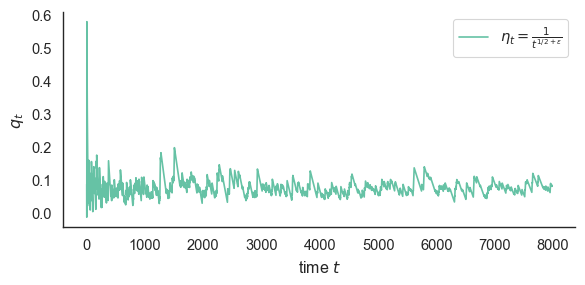

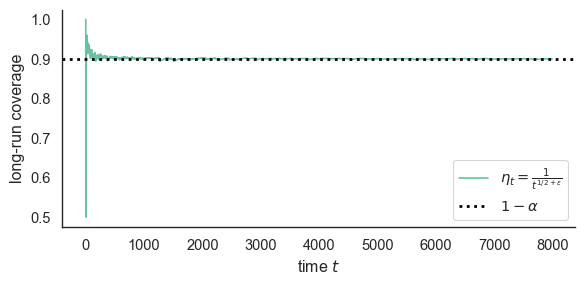

0.07689284732321419


In [1076]:
results_data_sp2 = compute_coverage_metrics(y_true_test2[seq_length:], super_preds_scaled2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_data_sp2, alpha=0.1, W=1000)
CI_sp_decaying2 = results_data_sp2['q_decaying'] * 2 
print(np.mean(results_data_sp2['q_decaying']))

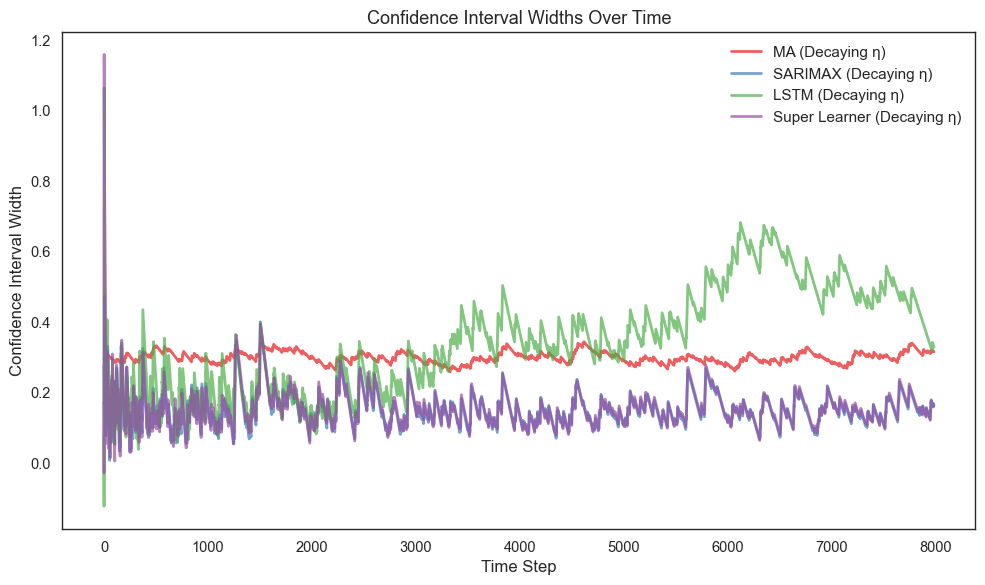

In [1077]:
plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set1", 4)
# Step 1: Generate a common index (e.g., time steps)
n = len(CI_lstm_decaying2)
x = list(range(n))

plt.plot(x, CI_ma_decaying2[-n:], label='MA (Decaying η)', linewidth=2,alpha = 0.7, color=colors[0])
plt.plot(x, CI_sarimax_decaying2[-n:], label='SARIMAX (Decaying η)', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(x, CI_lstm_decaying2, label='LSTM (Decaying η)', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(x, CI_sp_decaying2[-n:], label='Super Learner (Decaying η)', linewidth=2, alpha = 0.7, color=colors[3])

plt.title('Confidence Interval Widths Over Time', fontsize=13)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("ci_widths_set1.pdf", bbox_inches="tight")
plt.show()

In [892]:
print(f'mean coverage for Super Learner is:', np.mean(results_data_sp2['observed_coverages_decaying']))

mean coverage for Super Learner is: 0.9003130870381966


#### COMA

###### Adahage

Mean deterministic coverage: 0.8999373825923607
Mean randomized coverage: 0.8994364433312461
Mean CI width — COMA (det): 0.1526384512498436
Mean CI width — COMA (rand): 0.15239310377329235
Mean CI width — Super Learner: 0.15378569464642838


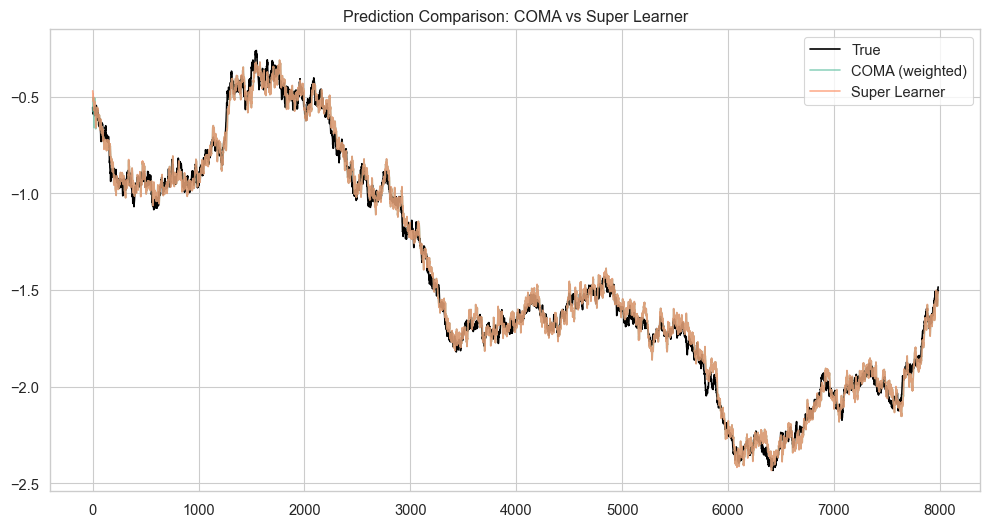

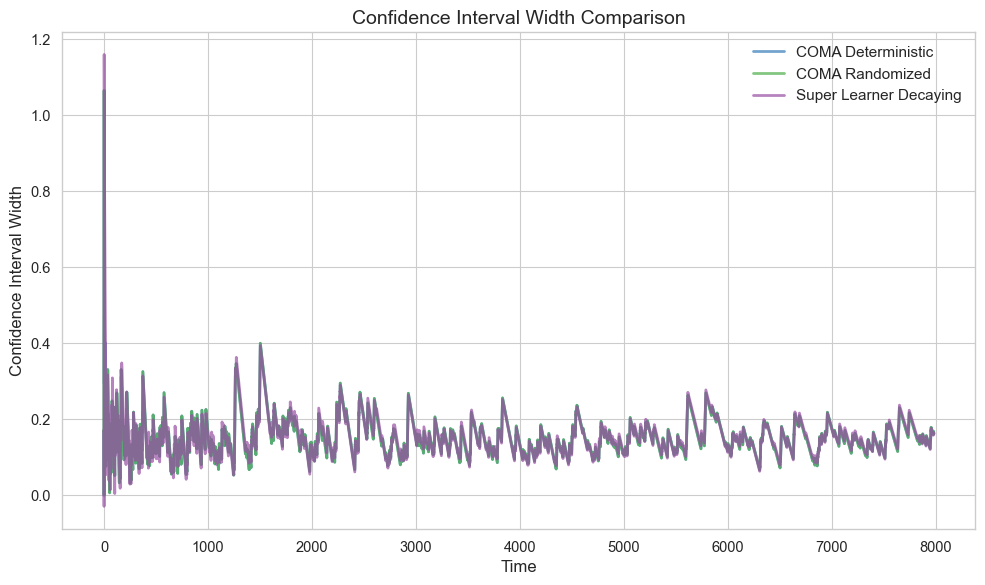

In [1097]:
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(results_jd_sa2['q_decaying']),
    len(results_jd_srm2['q_decaying']),
    #len(results_jd_srm_model2['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(CI_sp_decaying2),
    len(y_true_test2)
)

# --- Step 2: CI half-widths (2 * q_decaying) ---
ci_matrix2 = np.column_stack([
    CI_ma_decaying2[-min_len:],
    CI_sarimax_decaying2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying2[-min_len:],
    #2 * results_jd_lstm3_model2['q_decaying'][:min_len]

])
adahedAlg2 = adahedge(loss_matrix=ci_matrix2)

intervals_ma2 = np.column_stack([
    yhat_sa_jd2[-min_len:] - results_jd_sa2['q_decaying'][-min_len:],
    yhat_sa_jd2[-min_len:]  + results_jd_sa2['q_decaying'][-min_len:]
])

intervals_sarimax2 = np.column_stack([
    Yhat_jd_srm2[-min_len:]  - results_jd_srm2['q_decaying'][-min_len:],
    Yhat_jd_srm2[-min_len:]  + results_jd_srm2['q_decaying'][-min_len:]
])

intervals_lstm2 = np.column_stack([
    y_pred_lstm_sim2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm_sim2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])


intervals_list_plain2 = [intervals_ma2, intervals_sarimax2, intervals_lstm2]
weights_plain2 = adahedAlg2["weights"]

# --- Step 5: Align test labels ---
y_test_aligned2 = y_true_test2[-min_len:]

# --- Step 6: Run COMA ---
result_plain2 = coma_loop(intervals_list_plain2, weights_plain2, y_test_aligned2)

print("Mean deterministic coverage:", result_plain2["mean_m_cov"])
print("Mean randomized coverage:", result_plain2["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m   = result_plain2["pi_m"]
pi_wm  = result_plain2["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying2 = CI_sp_decaying2[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying2))

base_preds_matrix = np.column_stack([
    yhat_sa_jd2[-min_len:],
    Yhat_jd_srm2[-min_len:],
    y_pred_lstm_sim2[-min_len:]
])
# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned2, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds_scaled2[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot ---
plt.figure(figsize=(10, 6))

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying2, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

Mean deterministic coverage: 0.8998121477770821
Mean randomized coverage: 0.8995616781465248
Mean CI width — COMA (det): 0.1526384512498436
Mean CI width — COMA (rand): 0.15239310377329235
Mean CI width — COMA (det) + SL: 0.1526204623744919
Mean CI width — COMA (rand) + SL: 0.1523808343756434


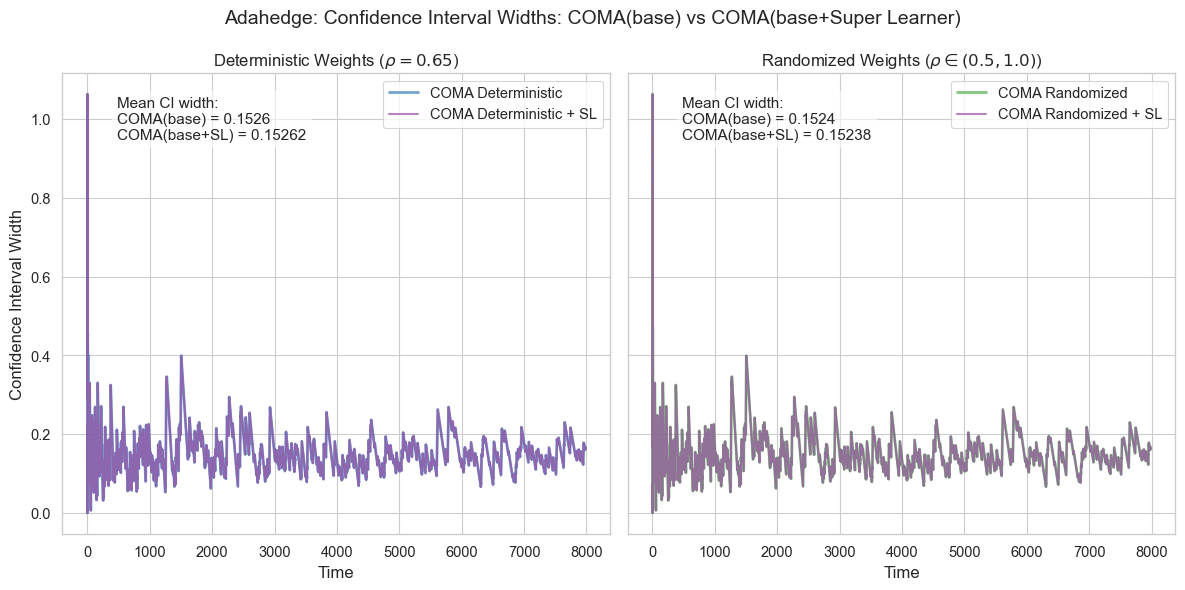

In [1113]:

min_len = min(
    len(results_jd_sa2['q_decaying']),
    len(results_jd_srm2['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(results_data_sp2['q_decaying']),
    len(y_true_test2)
)

ci_matrix_sl = np.column_stack([
    CI_ma_decaying2[-min_len:],
    CI_sarimax_decaying2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying2[-min_len:],
    CI_sp_decaying2[-min_len:]
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)

intervals_ma2 = np.column_stack([
    yhat_sa_jd2[-min_len:] 
    - results_jd_sa2['q_decaying'][-min_len:],
    yhat_sa_jd2[-min_len:] 
    + results_jd_sa2['q_decaying'][-min_len:]
])

intervals_sarimax2 = np.column_stack([
    Yhat_jd_srm2[-min_len:] 
    - results_jd_srm2['q_decaying'][-min_len:],
    Yhat_jd_srm2[-min_len:] 
    + results_jd_srm2['q_decaying'][-min_len:]
])


intervals_lstm2 = np.column_stack([
    y_pred_lstm_sim2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm_sim2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])



intervals_sp2 = np.column_stack([
    super_preds_scaled2[-min_len:] - results_data_sp2['q_decaying'][-min_len:],
    super_preds_scaled2[-min_len:] + results_data_sp2['q_decaying'][-min_len:]
])

# --- Step 4: Pack intervals + weights ---
intervals_list_sl2 = [intervals_ma2, intervals_sarimax2, intervals_lstm2, intervals_sp2]
weights_sl2 = adahedAlg_sl["weights"]

# --- Step 5: Align test labels ---
y_test_aligned2 = y_true_test2[-min_len:]

# --- Step 6: Run COMA ---
result_sl2 = coma_loop(intervals_list_sl2, weights_sl2, y_test_aligned2)

print("Mean deterministic coverage:", result_sl2["mean_m_cov"])
print("Mean randomized coverage:", result_sl2["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m_sl   = result_sl2["pi_m"]
pi_wm_sl  = result_sl2["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[1])
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.65$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Add mean values annotation
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.5f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Add mean values annotation
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.5f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Adahedge: Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()

In [1093]:
print("Mean AdaHedge weights (with SL):", np.mean(weights_sl2, axis=0))

Mean AdaHedge weights (with SL): [1.24793458e-03 9.98338711e-01 2.47968504e-04 1.65386311e-04]


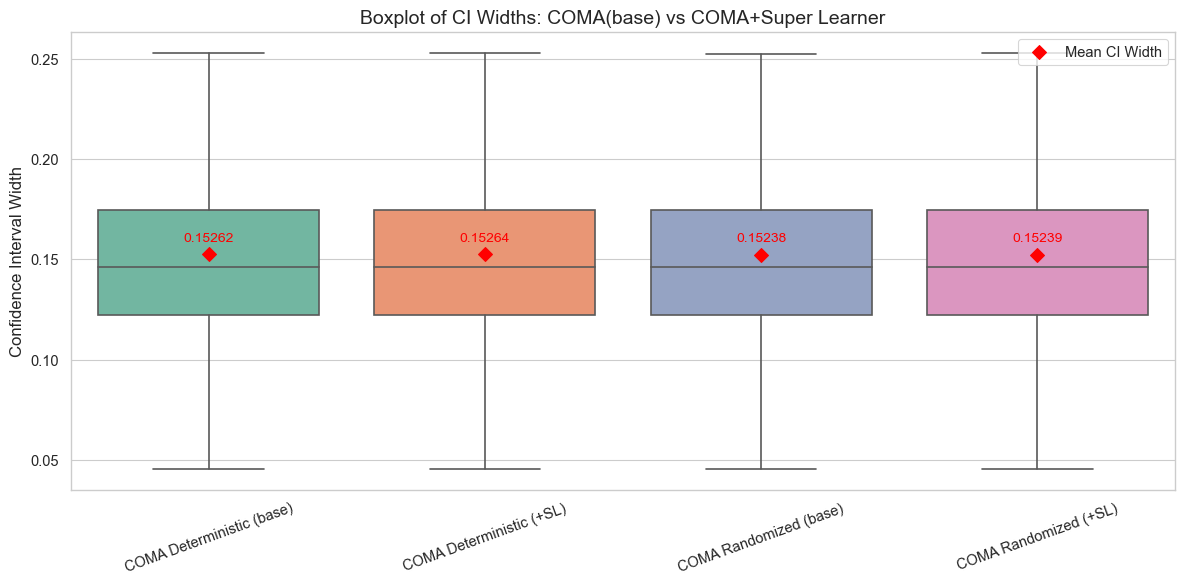

In [1114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Organize data into a long DataFrame
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl,
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 2: Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.boxplot(x="Method", y="CI Width", data=df_long,
                 palette="Set2", showfliers=False)

# Step 3: Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(means.index):
    ax.scatter(i, means[method], color="red", marker="D", s=50, zorder=3, label="Mean CI Width" if i == 0 else "")
    ax.text(i, means[method] + 0.005, f"{means[method]:.5f}",
            ha='center', va='bottom', fontsize=10, color="red")

# Step 4: Labels & formatting
plt.title("Boxplot of CI Widths: COMA(base) vs COMA+Super Learner", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

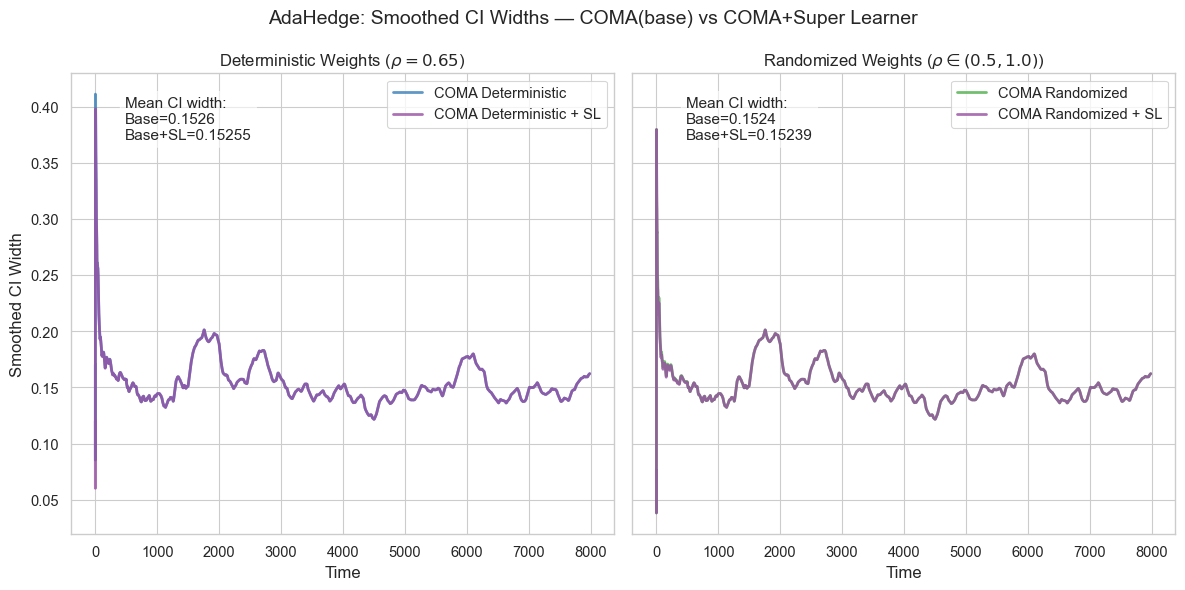

In [1095]:
# --- Helper: rolling mean smoother ---
def smooth_series(arr, window=500):
    return pd.Series(arr).rolling(window=window, min_periods=1).mean().to_numpy()

# --- Smooth the CI width series ---
smooth_det     = smooth_series(coma_width_det, window=500)
smooth_det_sl  = smooth_series(coma_width_det_sl, window=500)
smooth_rand    = smooth_series(coma_width_rand, window=500)
smooth_rand_sl = smooth_series(coma_width_rand_sl, window=500)

# --- Step 8: Smoothed Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Deterministic subplot
axes[0].plot(smooth_det, label='COMA Deterministic', linewidth=2, alpha=0.8, color=colors[1])
axes[0].plot(smooth_det_sl, label='COMA Deterministic + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.65$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Smoothed CI Width", fontsize=12)
axes[0].legend()

# Annotate mean values
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nBase={mean_det:.4f}\nBase+SL={mean_det_sl:.5f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# Randomized subplot
axes[1].plot(smooth_rand, label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(smooth_rand_sl, label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate mean values
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nBase={mean_rand:.4f}\nBase+SL={mean_rand_sl:.5f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("AdaHedge: Smoothed CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()